Import everything needed

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
2025-05-02 17:32:35.411377: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-02 17:32:35.435408: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


MONAI version: 1.3.0
Numpy version: 1.26.4
Pytorch version: 2.4.1+cu121
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: 865972f7a791bf7b42efbcd87c8402bd865b329e
MONAI __file__: /usr/local/lib/python3.10/dist-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: NOT INSTALLED or UNKNOWN VERSION.
ITK version: NOT INSTALLED or UNKNOWN VERSION.
Nibabel version: 5.3.2
scikit-image version: 0.21.0
scipy version: 1.8.0
Pillow version: 9.0.1
Tensorboard version: 2.16.2
gdown version: NOT INSTALLED or UNKNOWN VERSION.
TorchVision version: 0.19.1+cu121
tqdm version: 4.66.4
lmdb version: NOT INSTALLED or UNKNOWN VERSION.
psutil version: 5.9.5
pandas version: 1.3.5
einops version: 0.8.1
transformers version: NOT INSTALLED or UNKNOWN VERSION.
mlflow version: NOT INSTALLED or UNKNOWN VERSION.
pynrrd version: NOT INSTALLED or UNKNOWN VERSION.
clearml version: NOT INSTALLED or UNKNOWN VERSION.

For details about installing the optional depen

2025-05-02 17:32:35.856359: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


CUDA version: 12.1
Is CUDA available: True
Device name: NVIDIA GeForce RTX 4090
image shape: (512, 512, 75), mask shape: (512, 512, 75)


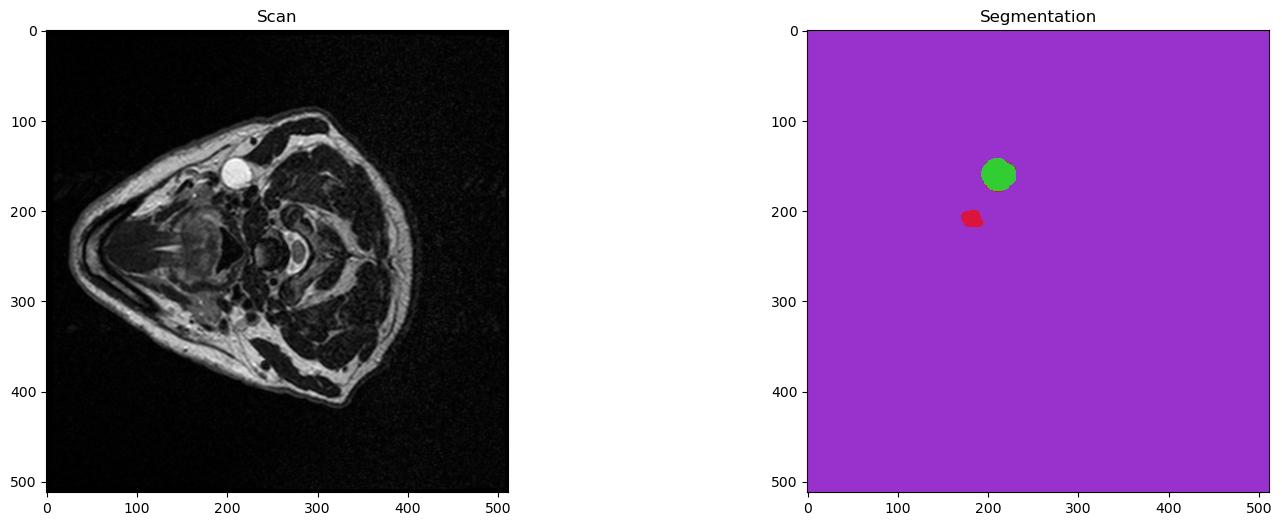

/tmp/tmpliv_ww72
Fold 5: 120 training, 10 validation


Loading dataset: 100%|██████████| 10/10 [00:05<00:00,  1.75it/s]


image shape: torch.Size([192, 192, 96]), mask shape: torch.Size([192, 192, 96])
image shape: torch.Size([512, 512, 96]), mask shape: torch.Size([512, 512, 96])


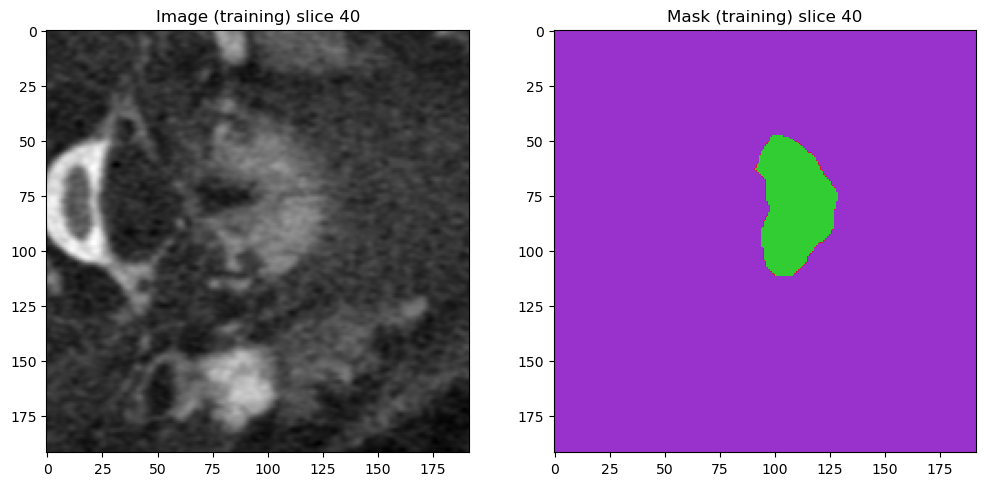

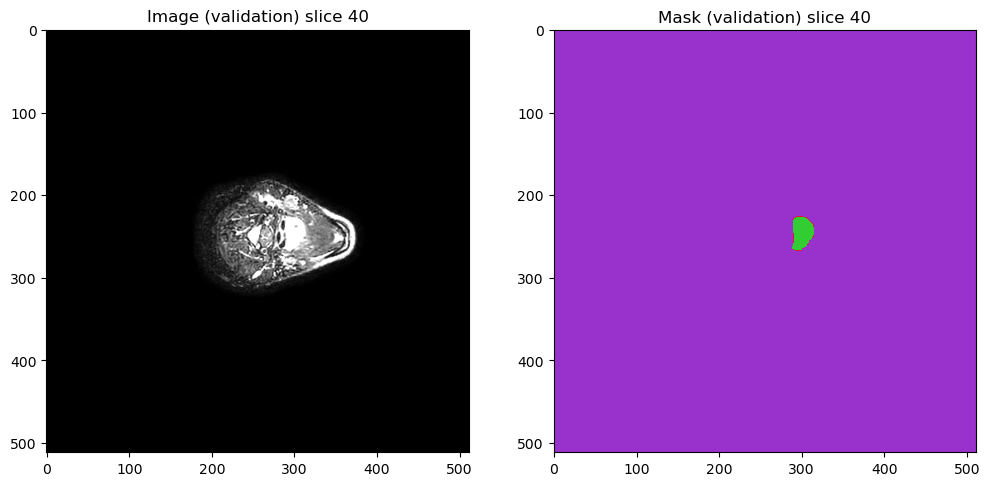

Using cuda
Epoch 1/100		............................................................Avg loss: 1.6232 		 in 57.3537s
Epoch 2/100		..........

In [ ]:
import sys

from fastai.metrics import PrecisionMulti, Recall
from jupyter_server.transutils import trans

from main_v7_unet import best_val_loss

print(sys.executable)

import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
import json
import shutil
import tempfile
import time
import glob

import matplotlib.pyplot as plt
import numpy as np
import nibabel as nib

from monai.losses import DiceLoss, DiceFocalLoss, DiceCELoss
from monai.inferers import sliding_window_inference
from monai import transforms
from monai.transforms import (
    AsDiscrete,
    Activations,
)

# Use sklearn for proper folding
from sklearn.model_selection import KFold

from monai.config import print_config
from monai.metrics import DiceMetric, ConfusionMatrixMetric
from monai.utils.enums import MetricReduction
from monai.networks.nets import SwinUNETR, UNETR, UNet
from monai import data
from monai.data import decollate_batch
from functools import partial

import torch


print_config()

In [2]:
print("CUDA version:", torch.version.cuda)
print("Is CUDA available:", torch.cuda.is_available())
print("Device name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "N/A")

CUDA version: 12.1
Is CUDA available: True
Device name: NVIDIA GeForce RTX 4090


image shape: (512, 512, 75), mask shape: (512, 512, 75)


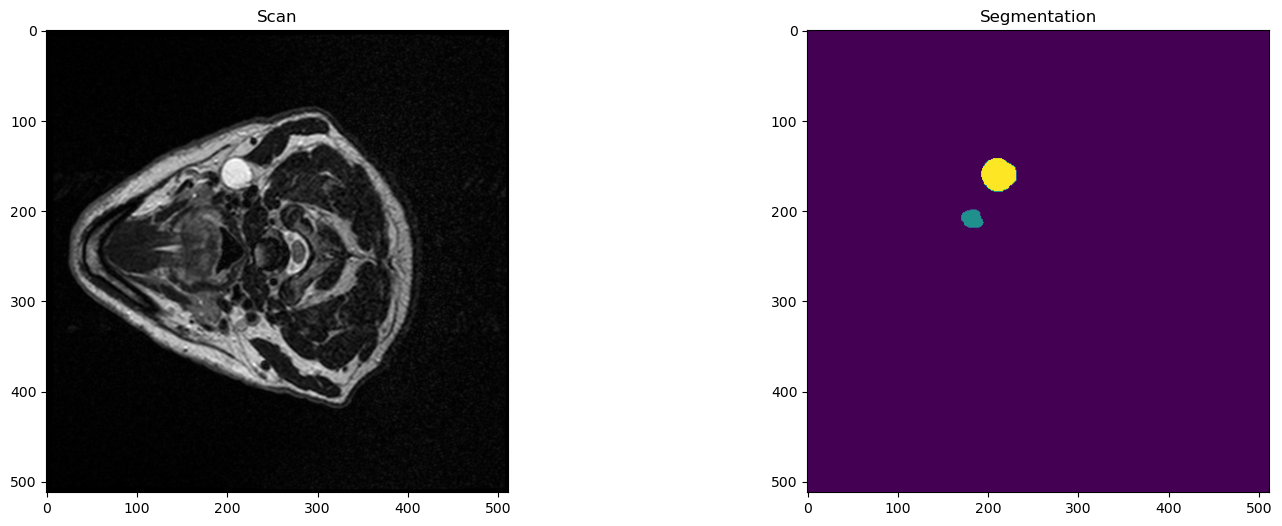

In [3]:
img_path = "/datasets/tdt4265/mic/open/HNTS-MRG/train/10/preRT/10_preRT_T2.nii.gz"
mask_path = "/datasets/tdt4265/mic/open/HNTS-MRG/train/10/preRT/10_preRT_mask.nii.gz"

img = nib.load(img_path).get_fdata()
mask = nib.load(mask_path).get_fdata()

print(f"image shape: {img.shape}, mask shape: {mask.shape}")

plt.figure("image", (18, 6))
plt.subplot(1, 2, 1)

plt.title("Scan")
plt.imshow(img[:, :, 40], cmap="gray")
plt.subplot(1, 2, 2)
plt.title("Segmentation")
plt.imshow(mask[:, :, 40])
plt.show()

Setup data directory

In [4]:
root_dir = tempfile.mkdtemp()
print(root_dir)

/tmp/tmpb2oqo39y


Setup average meter, fold reader, checkpoint saver

In [5]:
class AverageMeter(object):
    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = np.where(self.count > 0, self.sum / self.count, self.sum)

In [6]:
# Adjusts file paths using basedir
# Splits dataset into training and validation sets based on fold
def datafold_read(basedir, fold=0, nb_folds=5, seed=42):
    tr = []
    val = []

    # Get images and masks
    images = sorted(glob.glob(basedir + "/train/*/preRT/*_preRT_T2.nii.gz"))
    masks = sorted(glob.glob(basedir + "/train/*/preRT/*_preRT_mask.nii.gz"))

    data_dicts = [{"image": img, "mask": msk} for img, msk
                  in zip(images, masks)]

    # Split data into training and validation sets

    tr = data_dicts[int(len(data_dicts)/2):]
    val = data_dicts[:int(len(data_dicts)/2)]
    
    # return tr, val
    
    kf = KFold(n_splits=nb_folds, shuffle=True, random_state=seed)
    
    # Convert to indices for folding
    indices = list(range(len(data_dicts)))
    # Get the fold splits
    fold_splits = list(kf.split(indices))
    
    if fold >= nb_folds:
        raise ValueError(f"Fold {fold} is out of range (0-{nb_folds-1})")
    
    # Get the train and validation indices for the specified fold
    train_indices, val_indices = fold_splits[fold]
    
    # Extract the actual data dictionaries
    train_files = [data_dicts[i] for i in train_indices]
    val_files = [data_dicts[i] for i in val_indices]
    
    print(f"Fold {fold}: {len(train_files)} training, {len(val_files)} validation")
    
    return train_files, val_files

In [7]:
def save_checkpoint(model, epoch, filename="model.pt",
                    best_acc=0, dir_add=root_dir):
    state_dict = model.state_dict()
    save_dict = {"epoch": epoch, "best_acc": best_acc,
                 "state_dict": state_dict}
    filename = os.path.join(dir_add, filename)
    torch.save(save_dict, filename)
    print("Saving checkpoint", filename)

Setup dataloaders

In [8]:
"""
            transforms.CropForegroundd(
                keys=["image", "mask"],
                source_key="image",
                k_divisible=[roi[0], roi[1], roi[2]],
            ),
            transforms.RandSpatialCropd(
                keys=["image", "mask"],
                roi_size=[roi[0], roi[1], roi[2]],
                random_size=False,
            ),
            """

"""
transforms.RandFlipd(keys=["image", "mask"], prob=0.5, spatial_axis=0),
            transforms.RandFlipd(keys=["image", "mask"], prob=0.5, spatial_axis=1),
            transforms.RandFlipd(keys=["image", "mask"], prob=0.5, spatial_axis=2),
            transforms.NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
            transforms.RandScaleIntensityd(keys="image", factors=0.1, prob=1.0),
            transforms.RandShiftIntensityd(keys="image", offsets=0.1, prob=1.0),"""

def relabel_mask(mask):
    mask = mask.clone()
    mask[mask == 0] = 5 # placeholder
    mask[mask == 1] = 0
    mask[mask == 5] = 1
    mask[mask == 2] = 2
    return mask

def get_loader(batch_size, data_dir, fold, roi, nb_folds=5):
    data_dir = data_dir
    train_files, validation_files = datafold_read(basedir=data_dir, fold=fold, nb_folds=nb_folds)

    # Define transforms
    train_transform = transforms.Compose([
    transforms.LoadImaged(keys=["image", "mask"]),
        transforms.EnsureChannelFirstd(keys=["image", "mask"]),
        
        # Make sure mask is proper type
        # transforms.EnsureTyped(keys=["mask"], dtype=torch.long),
        
        transforms.Orientationd(keys=["image", "mask"], axcodes="RAS"),
        
        # Improved intensity normalization
        transforms.ScaleIntensityRanged(
            keys=["image"], 
            a_min=0, 
            a_max=1000,  # Adjust these values based on your MRI data
            b_min=0.0, 
            b_max=1.0, 
            clip=True
        ),
        
        transforms.CropForegroundd(
            keys=["image", "mask"], 
            source_key="image",
            margin=10  # Add margin to ensure no cropping of tumor regions
        ),
        
        transforms.ResizeWithPadOrCropd(keys=["image", "mask"], spatial_size=(512, 512, 96)),

        # Add augmentations
        transforms.RandRotate90d(keys=["image", "mask"], prob=0.5, max_k=3),
        transforms.RandFlipd(keys=["image", "mask"], prob=0.5, spatial_axis=[0, 1, 2]),
        transforms.RandShiftIntensityd(keys=["image"], prob=0.5, offsets=0.1),
        transforms.RandZoomd(keys=["image", "mask"], prob=0.5, min_zoom=0.9, max_zoom=1.1),
        transforms.RandGaussianNoised(keys=["image"], prob=0.3, mean=0.0, std=0.1),
        transforms.RandGaussianSmoothd(keys=["image"], prob=0.3, sigma_x=(0.5, 1.0)),
        transforms.RandAdjustContrastd(keys=["image"], prob=0.3, gamma=(0.7, 1.3)),
        
        # Sample patches with better balance of tumor regions
        transforms.RandCropByPosNegLabeld(
            keys=["image", "mask"], 
            label_key="mask", 
            spatial_size=roi, 
            pos=1.0,  # Probability of selecting positive samples
            neg=0.2,  # Lower probability for background samples
            num_samples=4,
            allow_smaller=True  # Allow patches smaller than spatial_size
        ),
        
        # Skip relabeling if your labels are already correct (0=background, 1=tumor1, 2=tumor2)
        transforms.Lambdad(keys=["mask"], func=relabel_mask),
        
        # Convert to one-hot for 3 classes
        transforms.AsDiscreted(keys=["mask"], to_onehot=3),
        
        transforms.ToTensord(keys=["image", "mask"]),
])
    
    val_transform = transforms.Compose([
    transforms.LoadImaged(keys=["image", "mask"]),
        transforms.EnsureChannelFirstd(keys=["image", "mask"]),
        
        # transforms.EnsureTyped(keys=["mask"], dtype=torch.long),
        
        transforms.Orientationd(keys=["image", "mask"], axcodes="RAS"),
        
        # Match training normalization method
        transforms.ScaleIntensityRanged(
            keys=["image"], 
            a_min=0, 
            a_max=1000,  # Adjust these values based on your MRI data
            b_min=0.0, 
            b_max=1.0, 
            clip=True
        ),
        
        transforms.CropForegroundd(
            keys=["image", "mask"], 
            source_key="image",
            margin=10
        ),
        
        transforms.ResizeWithPadOrCropd(keys=["image", "mask"], spatial_size=(512, 512, 96)),
        
        # Skip relabeling if your labels are already correct
        transforms.Lambdad(keys=["mask"], func=relabel_mask),
        
        transforms.AsDiscreted(keys=["mask"], to_onehot=3),
        
        transforms.ToTensord(keys=["image", "mask"]),
])

    # Make datasets and dataloaders
    # CACHE DATASET?
    # num_workers to 2?
    train_ds = data.CacheDataset(data=train_files, transform=train_transform)
    train_loader = data.DataLoader(train_ds,
        batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True, persistent_workers=False  # num_workers = 8?
    )
    val_ds = data.CacheDataset(data=validation_files, transform=val_transform)
    val_loader = data.DataLoader(val_ds,
        batch_size=1, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=False
    )

    return train_loader, val_loader

Setup data directory and hyperparameters

In [9]:
data_dir = "/datasets/tdt4265/mic/open/HNTS-MRG"

roi = (256,256,96) # (64,64,64)
batch_size = 2
sw_batch_size = 4
nb_folds = 13 # JUST TO TEST FOR SMALLER INFERENCE TIME AT VALIDATION
fold = 5 # 5
infer_overlap = 0.5
max_epochs = 150
val_every = 4

train_loader, val_loader = get_loader(batch_size, data_dir, fold, roi, nb_folds=nb_folds)

/usr/local/lib/python3.10/dist-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.croppad.dictionary CropForegroundd.__init__:allow_smaller: Current default value of argument `allow_smaller=True` has been deprecated since version 1.2. It will be changed to `allow_smaller=False` in version 1.5.
  warn_deprecated(argname, msg, warning_category)


Fold 5: 120 training, 10 validation


Loading dataset: 100%|██████████| 10/10 [00:05<00:00,  1.74it/s]


Visualize and verify transformations

In [10]:
check_train_data = next(iter(train_loader))
check_val_data = next(iter(val_loader))
image_train, mask_train = (check_train_data["image"][0][0], check_train_data["mask"][0][0])
image_val, mask_val = (check_val_data["image"][0][0], check_val_data["mask"][0][0])

# Find a slice with visible tumors on the mask
slice_i = 65
for i in range(10,90):
    if len(np.unique(mask_train[:,:,i])) > 1:
        slice_i = i + 3
        break

print(f"image shape: {image_train.shape}, mask shape: {mask_train.shape}")
print(f"image shape: {image_val.shape}, mask shape: {mask_val.shape}")

plt.figure("check", (12,6))
plt.subplot(1,2,1)
plt.title(f"Image (training) slice {slice_i}")
plt.imshow(image_train[:,:,slice_i], cmap="gray")
plt.subplot(1,2,2)
plt.title(f"Mask (training) slice {slice_i}")
plt.imshow(mask_train[:,:,slice_i])
plt.show()

plt.figure("check", (12,6))
plt.subplot(1,2,1)
plt.title(f"Image (validation) slice {slice_i}")
plt.imshow(image_val[:,:,slice_i], cmap="gray")
plt.subplot(1,2,2)
plt.title(f"Mask (validation) slice {slice_i}")
plt.imshow(mask_val[:,:,slice_i])
plt.show()

KeyboardInterrupt: 

Create SwinUNETR model

In [ ]:
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using " + "cuda" if torch.cuda.is_available() else "cpu")

model = UNet(
    spatial_dims=3,
    in_channels=1,
    out_channels=3,
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2),
    num_res_units=2,
    norm="batch",
    dropout=0.2 # to prevent overfitting
).to(device)


Using cuda


Define optimizer and loss function

In [23]:
from monai.metrics import HausdorffDistanceMetric

torch.backends.cudnn.benchmark = True

import warnings
warnings.filterwarnings('ignore')

torch.cuda.empty_cache()

from torch.cuda.amp import autocast, GradScaler

# Class weights for loss function - adjust based on class prevalence
# Give higher weights to tumor classes if they're less common
class_weights = torch.tensor([0.2, 1.0, 1.0]).to(device)  # Example weights

# Use multi-class loss function
loss_function = DiceCELoss(
    to_onehot_y=False,  # We already converted to one-hot in the transforms
    softmax=True,       # Use softmax for multi-class (not sigmoid)
    ce_weight=class_weights
)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs, eta_min=1e-6)
dice_metric = DiceMetric(include_background=False, reduction=MetricReduction.MEAN_BATCH, get_not_nans=True)
confusion_metric = ConfusionMatrixMetric(
    metric_name=["precision", "recall"], 
    include_background=False,
    reduction="mean",                    # Average over the batch
    get_not_nans=True                    # Return not NaN counts
)

"""
post_pred = transforms.Compose([
    transforms.Activationsd(keys="pred", softmax=True),  # softmax instead of sigmoid
    transforms.AsDiscreted(keys="pred", argmax=True),    # argmax instead of threshold
    transforms.ToOneHotd(keys="pred", num_classes=3)     # Convert back to one-hot for metric calculation
])
"""

# Metrics for multi-class evaluation
hausdorff_metric = HausdorffDistanceMetric(include_background=False, percentile=95.0)

scaler = GradScaler()
max_epochs = 100 # 100

epoch_losses = []
validation_dice_losses = []
validation_hausdorff = []
validation_precision = []
validation_recall = []

# Create directory for saving models
os.makedirs("./models", exist_ok=True)

best_metric = 0

model.load_state_dict(torch.load("./models/best.pth", weights_only=True))

best_val_loss = 1000

for epoch in range(max_epochs):
    print(f"Epoch {epoch + 1}/{max_epochs}\t\t", end="")
    model.train()
    epoch_loss = 0
    
    for batch_data in train_loader:
        inputs = batch_data["image"].to(device, non_blocking=True)
        labels = batch_data["mask"].to(device, non_blocking=True)
        
        # print(torch.unique(labels)) # should be 0,1

        # Clear out the gradients of all parameters that the optimizer is tracking
        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            outputs = model(inputs)
            loss = loss_function(outputs, labels)

        # Backward pass with scaling
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()

        print(".", end="")
    # torch.cuda.empty_cache()
    
    # Update learning rate
    scheduler.step()
    
    avg_loss = epoch_loss / len(train_loader)
    print(f"Avg loss: {avg_loss:.4f}")
    
    """
    # Validation
    if (epoch + 1) % val_every == 0:
        print("VALIDATING\t\t",end="")
        model.eval()
        
        with torch.no_grad():
            
            val_dice = 0
            val_hausdorff = 0
            print(f"({len(val_loader)}) ", end="")
            for val_data in val_loader:
                val_inputs = val_data["image"].to(device)
                val_labels = val_data["mask"].to(device)
                
                # Use sliding window inference for better validation
                roi_size = roi
                val_outputs = sliding_window_inference(
                    val_inputs, roi_size, sw_batch_size, model, overlap=infer_overlap
                )
                
                # Apply post-processing - softmax activation for multi-class
                val_outputs_softmax = torch.softmax(val_outputs, dim=1)
                
                # Convert to discrete segmentation via argmax
                val_outputs_argmax = torch.argmax(val_outputs_softmax, dim=1, keepdim=True)
                
                # Convert argmax result to one-hot format for metric calculation
                val_outputs_onehot = torch.zeros_like(val_outputs_softmax)
                for i in range(val_outputs_softmax.shape[1]):
                    val_outputs_onehot[:, i:i+1] = (val_outputs_argmax == i)
                
                # Compute metrics
                dice_metric(y_pred=val_outputs_onehot, y=val_labels)
                hausdorff_metric(y_pred=val_outputs_onehot, y=val_labels)
                confusion_metric(y_pred=val_outputs_onehot, y=val_labels)
                
                print("*", end="")
            
            # Aggregate metrics
            metric_dice = dice_metric.aggregate()[0][0]
            metric_hausdorff = hausdorff_metric.aggregate().item()
            metrics = confusion_metric.aggregate()
            precision = metrics[0][0][0]
            recall = metrics[1][0][0]

            dice_metric.reset()
            hausdorff_metric.reset()
            confusion_metric.reset()
            
            # Add to history for further plotting
            validation_dice_losses.append(metric_dice)
            validation_hausdorff.append(metric_hausdorff)
            validation_precision.append(precision)
            validation_recall.append(recall)
            
            # print(metric_dice)
            
            print(f"\n\t\t\tValidation Dice: {metric_dice:.4f}")
            print(f"\t\t\tValidation Hausdorff Distance (95%): {metric_hausdorff:.4f}")
            print(f"\t\t\tPrecision: {precision:.4f}")
            print(f"\t\t\tRecall: {recall:.4f}", end="")
            # print(metrics)
            
            # Save best model
            if metric_dice > best_metric:
                best_metric = metric_dice
                best_metric_epoch = epoch + 1
                torch.save(model.state_dict(), f"./models/best_model_fold{fold}.pth")
                print("\t\t\tSaved new best model")
                
            print("-------------------------------------------------------------------------------------------------")
            """
            
    # Validation
    if (epoch + 1) % val_every == 0:
        print("VALIDATING\t\t",end="")
        model.eval()
        
        val_loss = 0
        val_step = 0
        val_start = time.time()
        with torch.no_grad():
            for val_data in val_loader:
                val_step += 1
                val_inputs, val_labels = val_data["image"].to(device), val_data["mask"].to(device)
                val_outputs = model(val_inputs)
                val_loss += loss_function(val_outputs, val_labels).item()

                try:
                    val_outputs_onehot = torch.zeros_like(val_outputs)
                    for i in range(val_outputs.shape[1]):
                        val_outputs_onehot[:, i:i+1] = (val_outputs == i)
                        
                    dice_metric(y_pred=val_outputs_onehot, y=val_labels)
                    hausdorff_metric(y_pred=val_outputs_onehot, y=val_labels)
                    confusion_metric(y_pred=val_outputs_onehot, y=val_labels)
                    
                    print("no")
                except:
                    print("", end="")
                    dice_metric(y_pred=val_outputs, y=val_labels)
                    hausdorff_metric(y_pred=val_outputs, y=val_labels)
                    confusion_metric(y_pred=val_outputs, y=val_labels)
                
                print("*", end="")
        
        val_loss /= val_step
        print(f"Validation loss: {val_loss:.4f} \t\t in {time.time() - val_start:.4f}s")
        
        # Learning rate adjustment
        scheduler.step(val_loss)
        
        # Aggregate metrics
        metric_dice = dice_metric.aggregate()[0][0]
        metric_hausdorff = hausdorff_metric.aggregate().item()
        metrics = confusion_metric.aggregate()
        precision = metrics[0][0][0]
        recall = metrics[1][0][0]

        dice_metric.reset()
        hausdorff_metric.reset()
        confusion_metric.reset()
            
        # Add to history for further plotting
        validation_dice_losses.append(metric_dice)
        validation_hausdorff.append(metric_hausdorff)
        validation_precision.append(precision)
        validation_recall.append(recall)
            
        # print(metric_dice)
            
        print(f"\n\t\t\tValidation Dice: {metric_dice:.4f}")
        print(f"\t\t\tValidation Hausdorff Distance (95%): {metric_hausdorff:.4f}")
        print(f"\t\t\tPrecision: {precision:.4f}")
        print(f"\t\t\tRecall: {recall:.4f}", end="")
        
        # Save model if validation improves
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), "best_model.pth")
            print("Model saved!")
    
    # Add to epoch losses
    epoch_losses.append(avg_loss)

Epoch 1/100		............................................................Avg loss: 0.3104
Epoch 2/100		............................................................Avg loss: 0.3087
Epoch 3/100		............................................................Avg loss: 0.3164
Epoch 4/100		............................................................Avg loss: 0.3089
VALIDATING		**********Validation loss: 0.3670 		 in 12.7591s

			Validation Dice: 0.9992
			Validation Hausdorff Distance (95%): 0.0000
			Precision: 0.0000
			Recall: 0.0000Model saved!
Epoch 5/100		............................................................Avg loss: 0.3107
Epoch 6/100		............................................................Avg loss: 0.3077
Epoch 7/100		............................................................Avg loss: 0.3044
Epoch 8/100		............................................................Avg loss: 0.3007
VALIDATING		**********Validation loss: 0.3814 		 in 9.3214s

			Validation Dice: 0.9992
			Va

KeyboardInterrupt: 

Plot loss

In [18]:
torch.save(model.state_dict(), f"./models/best_2.pth")

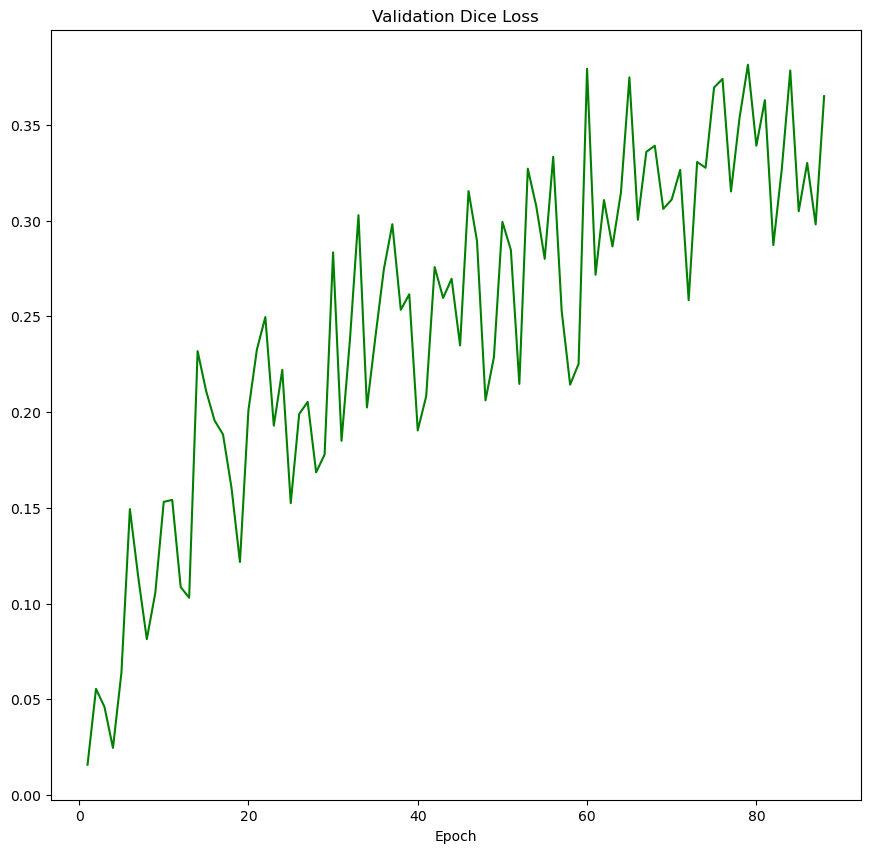

In [ ]:
plt.figure("training", figsize=(23, 10))
plt.subplot(1, 2, 1)
plt.title("Validation Dice Loss")
plt.xlabel("Epoch")
plt.plot(np.arange(1, +1), validation_dice_losses, color="green")

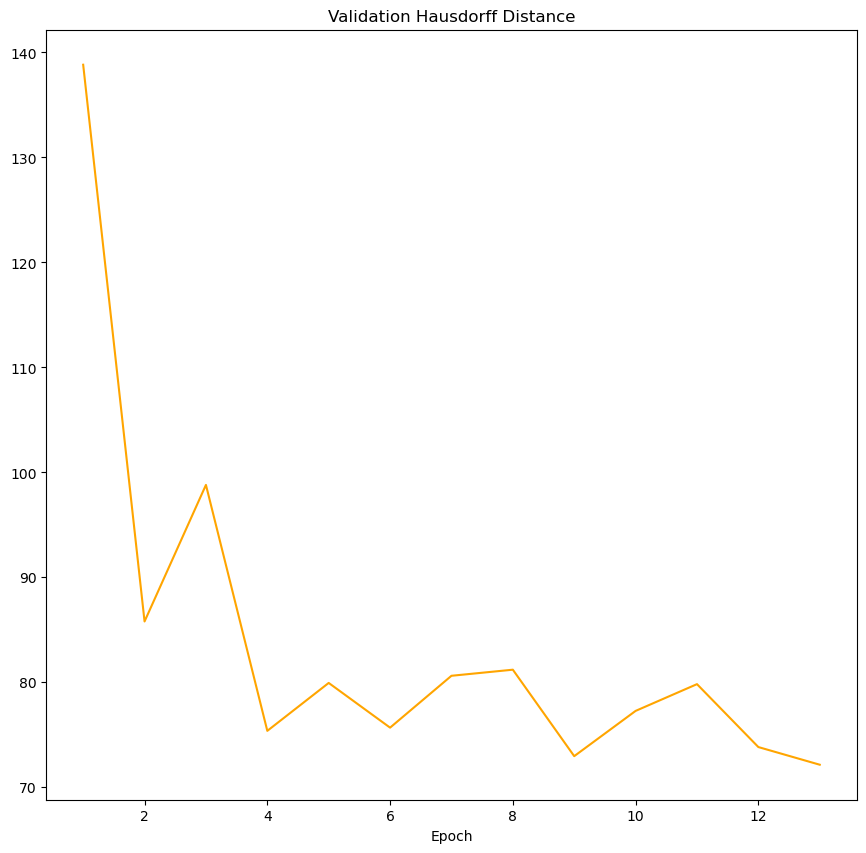

In [22]:
validation_epochs = [4, 8, 12, 16, 20, 24, 28, 32, 36, 40, 44, 48, 52]
plt.figure("training", figsize=(23, 10))
plt.subplot(1, 2, 1)
plt.title("Validation Hausdorff Distance")
plt.xlabel("Epoch")
plt.plot(np.arange(1, 13+1), validation_hausdorff, color="orange")

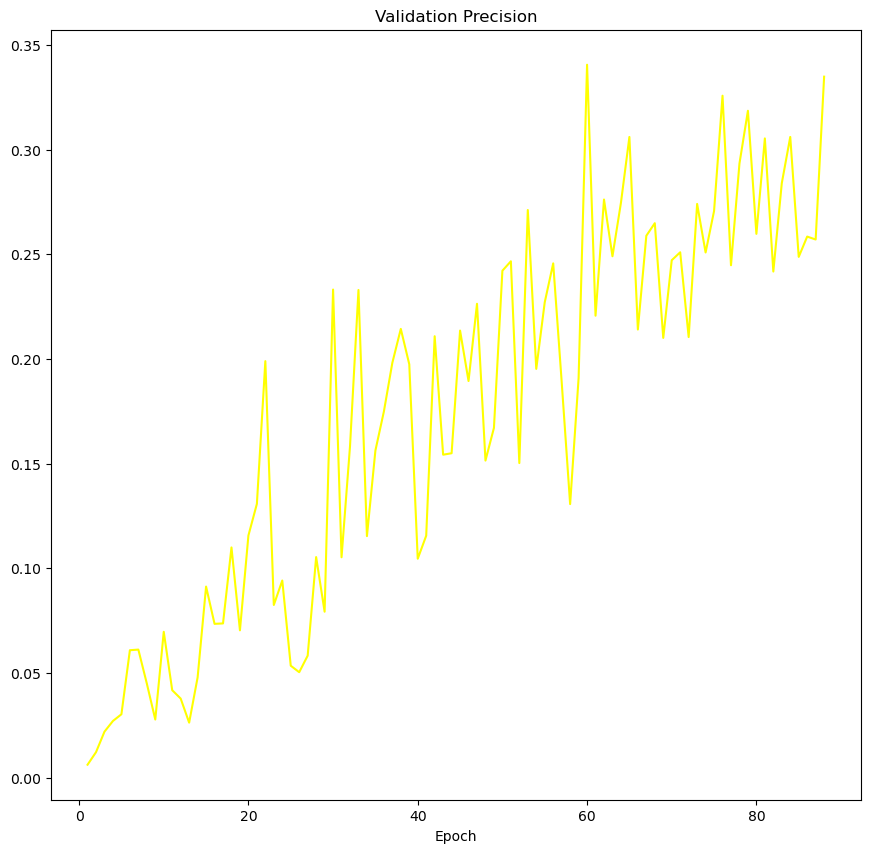

In [ ]:
plt.figure("training", figsize=(23, 10))
plt.subplot(1, 2, 1)
plt.title("Validation Precision")
plt.xlabel("Epoch")
plt.plot(np.arange(1, 88+1), validation_precision, color="yellow")

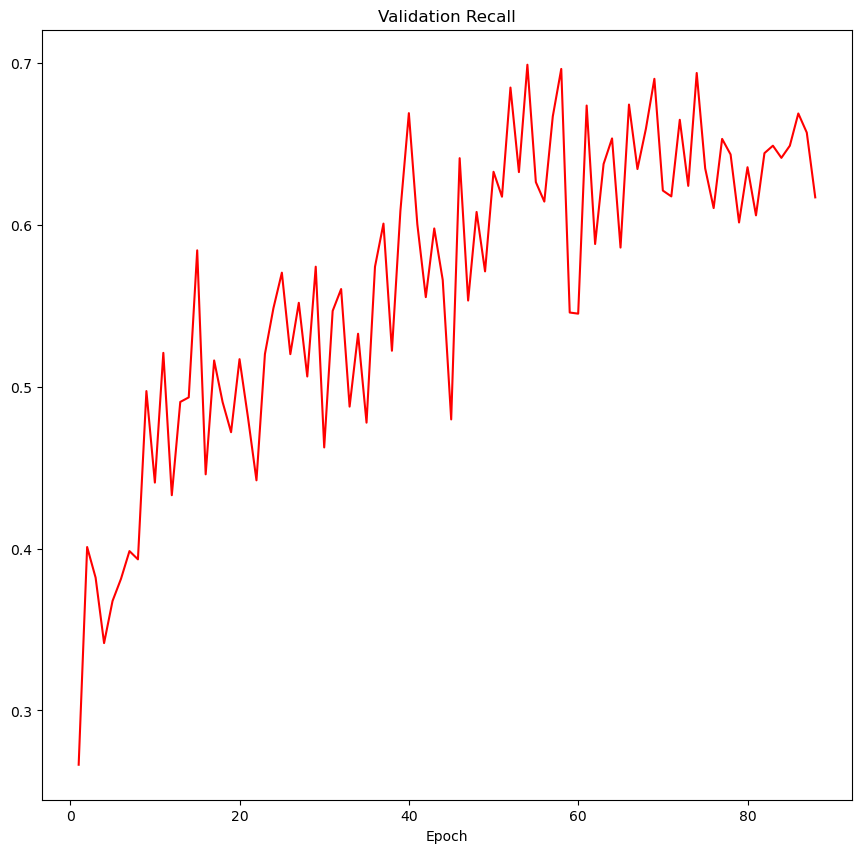

In [ ]:
plt.figure("training", figsize=(23, 10))
plt.subplot(1, 2, 1)
plt.title("Validation Recall")
plt.xlabel("Epoch")
plt.plot(np.arange(1, 88+1), validation_recall, color="red")

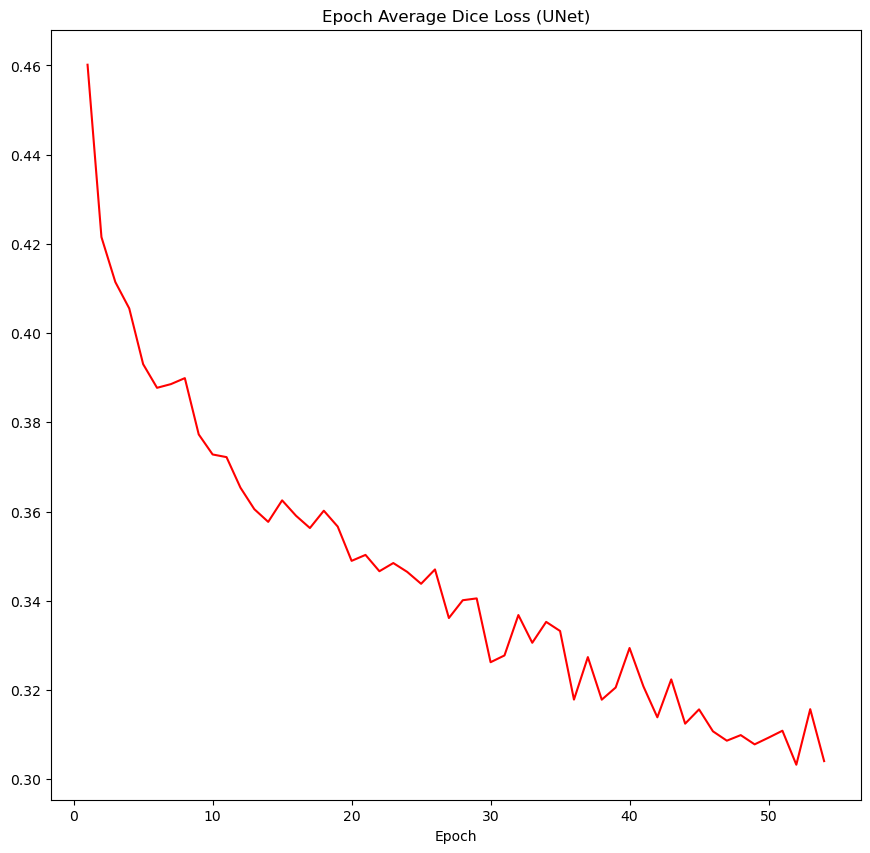

In [19]:
plt.figure("training", figsize=(23, 10))
plt.subplot(1, 2, 1)
plt.title("Epoch Average Dice Loss (UNet)")
plt.xlabel("Epoch")
plt.plot(np.arange(1, 54+1), epoch_losses, color="red")

Create dataloader for the test set

In [24]:
def test_data_read(basedir):

    # Get images and masks
    images = sorted(glob.glob(basedir + "/test/*/preRT/*_preRT_T2.nii.gz"))
    masks = sorted(glob.glob(basedir + "/test/*/preRT/*_preRT_mask.nii.gz"))

    data_dicts = [{"image": img, "mask": msk} for img, msk in zip(images, masks)]
    
    return data_dicts

"""

def get_test_loader(batch_size, data_dir, fold, roi):
    data_dir = data_dir
    test_files = test_data_read(data_dir)

    # Define transforms
    test_transform = transforms.Compose([
    transforms.LoadImaged(keys=["image", "mask"]),
    transforms.EnsureChannelFirstd(keys=["image", "mask"]),
        
    # transforms.EnsureTyped(keys=["mask"], dtype=torch.long),  
    transforms.Lambdad(keys=["mask"], func=relabel_mask),
        
    transforms.ScaleIntensityRanged(keys=["image"], a_min=-1000, a_max=1000, b_min=0.0, b_max=1.0, clip=True),
    
    transforms.CropForegroundd(keys=["image", "mask"], source_key="image"),
    transforms.ResizeWithPadOrCropd(keys=["image", "mask"], spatial_size=(512, 512, 96)),
    
    transforms.ToTensord(keys=["image", "mask"]),
    ])

    # Make datasets and dataloaders
    test_ds = data.Dataset(data=test_files, transform=test_transform)
    test_loader = data.DataLoader(test_ds,
        batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True, persistent_workers=False  # num_workers = 8?
    )

    return test_loader

"""

def get_test_loader(batch_size, data_dir, fold, roi):
    data_dir = data_dir
    test_files = test_data_read(data_dir)

    # Define transforms - should match preprocessing in training
    test_transform = transforms.Compose([
        transforms.LoadImaged(keys=["image", "mask"]),
        transforms.EnsureChannelFirstd(keys=["image", "mask"]),
        
        # Ensure consistent orientation
        transforms.Orientationd(keys=["image", "mask"], axcodes="RAS"),
        
        # Use same normalization as training
        transforms.NormalizeIntensityd(keys=["image"], channel_wise=True),
        # OR if you switch training to ScaleIntensityRanged:
        # transforms.ScaleIntensityRanged(keys=["image"], a_min=-1000, a_max=1000, b_min=0.0, b_max=1.0, clip=True),
        
        # Keep consistent with training preprocessing
        transforms.CropForegroundd(keys=["image", "mask"], source_key="image"),
        transforms.ResizeWithPadOrCropd(keys=["image", "mask"], spatial_size=(512, 512, 96)),
        
        # Ensure mask has proper format
        transforms.EnsureTyped(keys=["mask"], dtype=torch.long),
        
        # Convert to one-hot for 3 classes (background + 2 tumor types)
        transforms.AsDiscreted(keys=["mask"], to_onehot=3),
        
        transforms.ToTensord(keys=["image", "mask"]),
    ])

    # Make datasets and dataloaders
    test_ds = data.Dataset(data=test_files, transform=test_transform)
    test_loader = data.DataLoader(
        test_ds,
        batch_size=1, 
        shuffle=False,  # No shuffling for test data
        num_workers=2, 
        pin_memory=True
    )

    return test_loader

torch.Size([8, 1, 96, 96, 96])


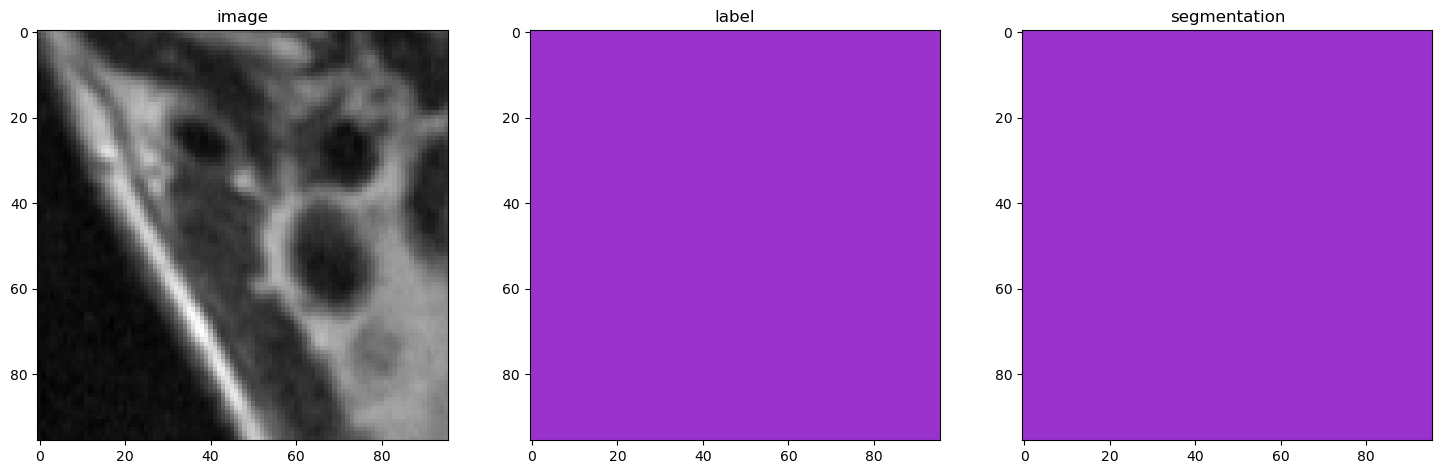

torch.Size([8, 1, 96, 96, 96])


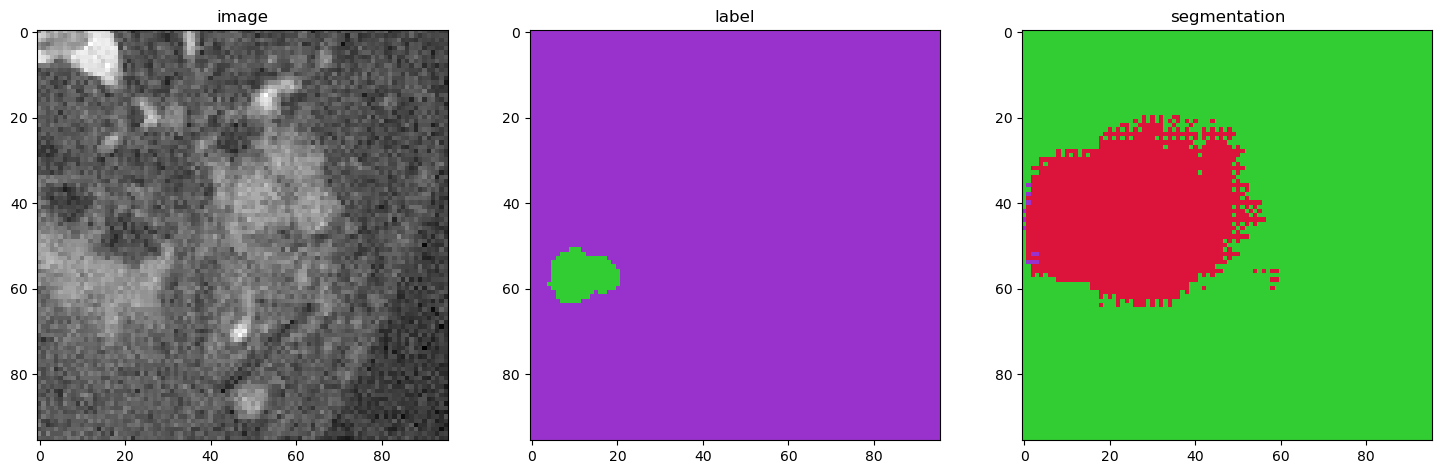

torch.Size([8, 1, 96, 96, 96])


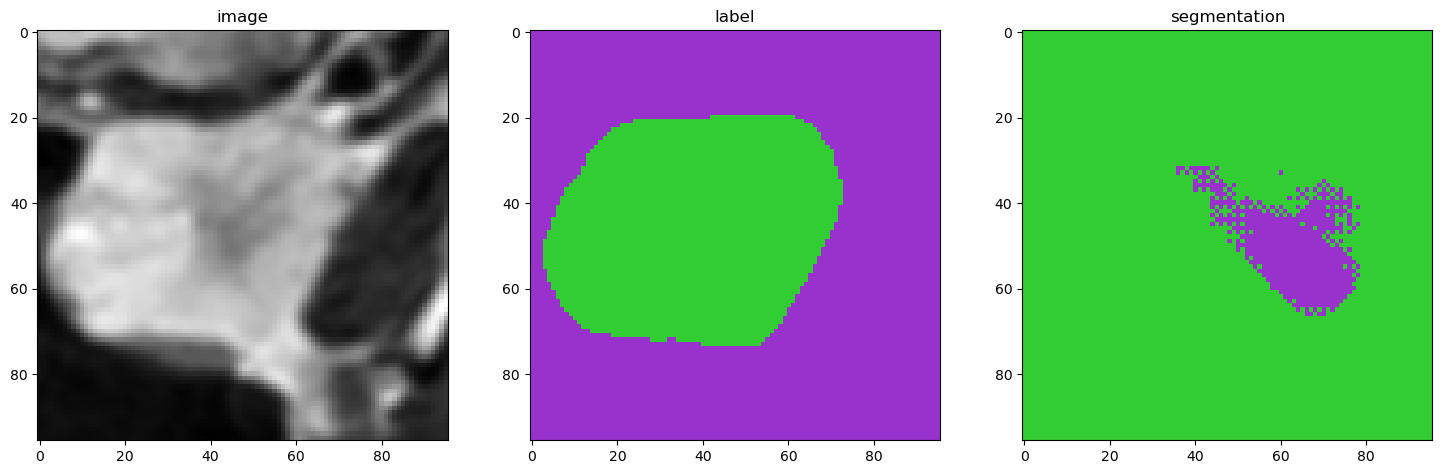

torch.Size([8, 1, 96, 96, 96])


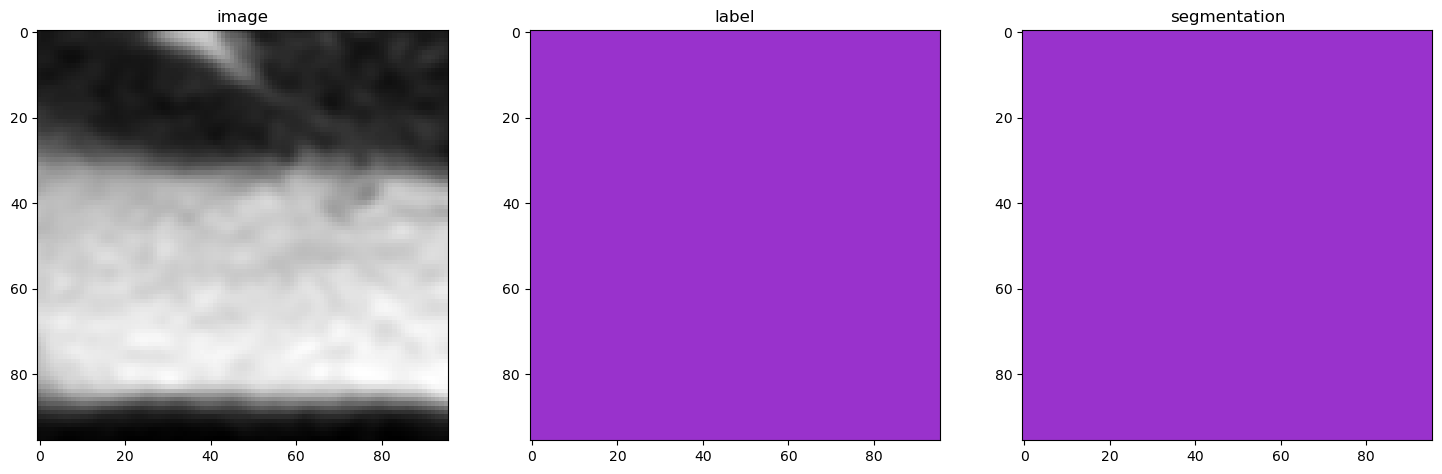

torch.Size([8, 1, 96, 96, 96])


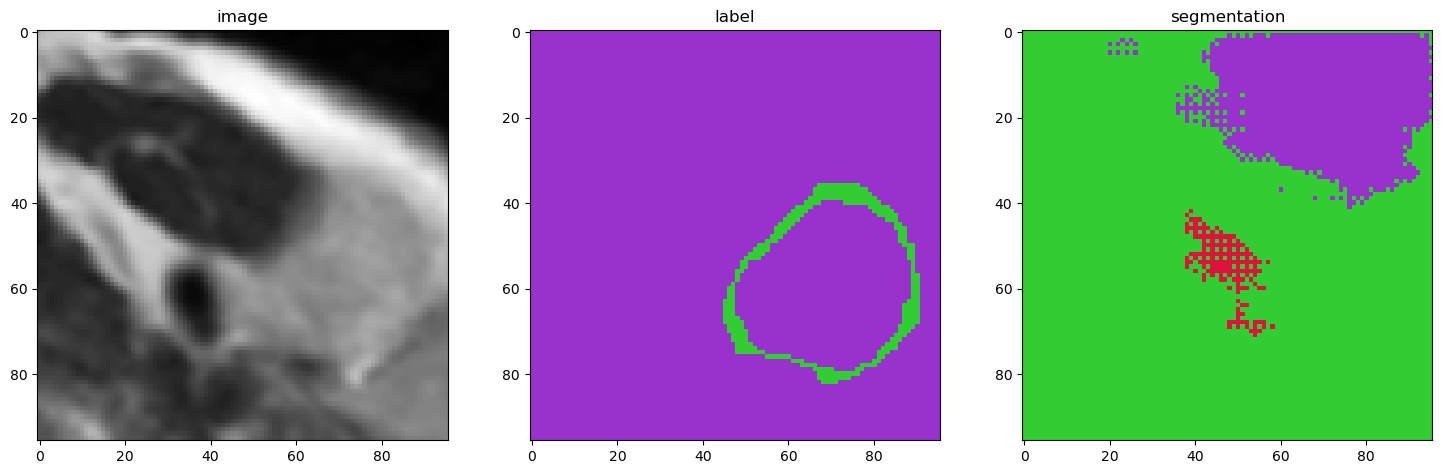

torch.Size([8, 1, 96, 96, 96])


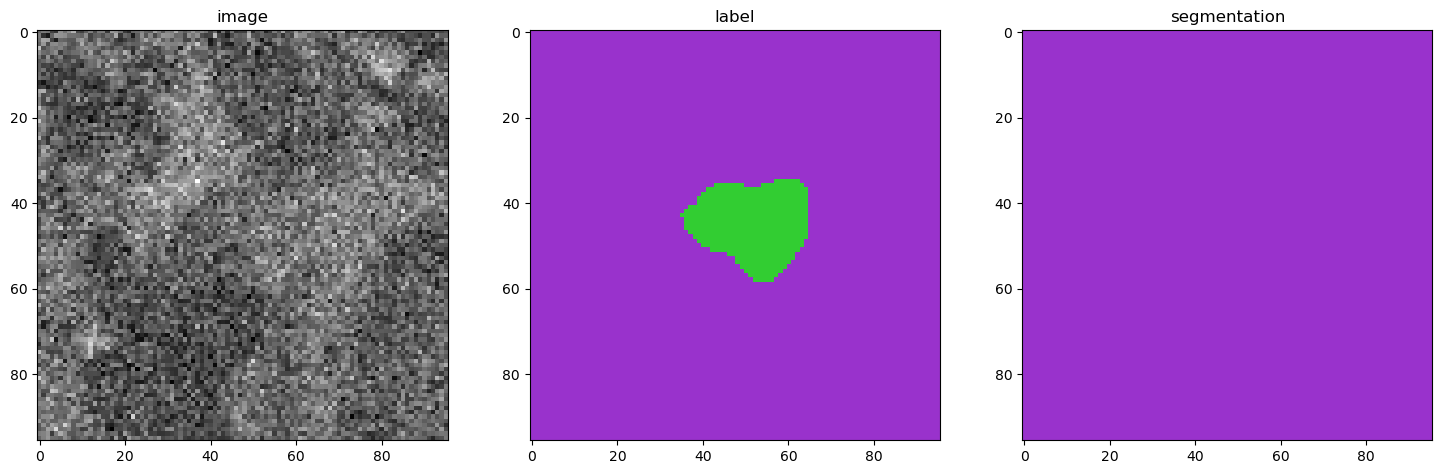

torch.Size([8, 1, 96, 96, 96])


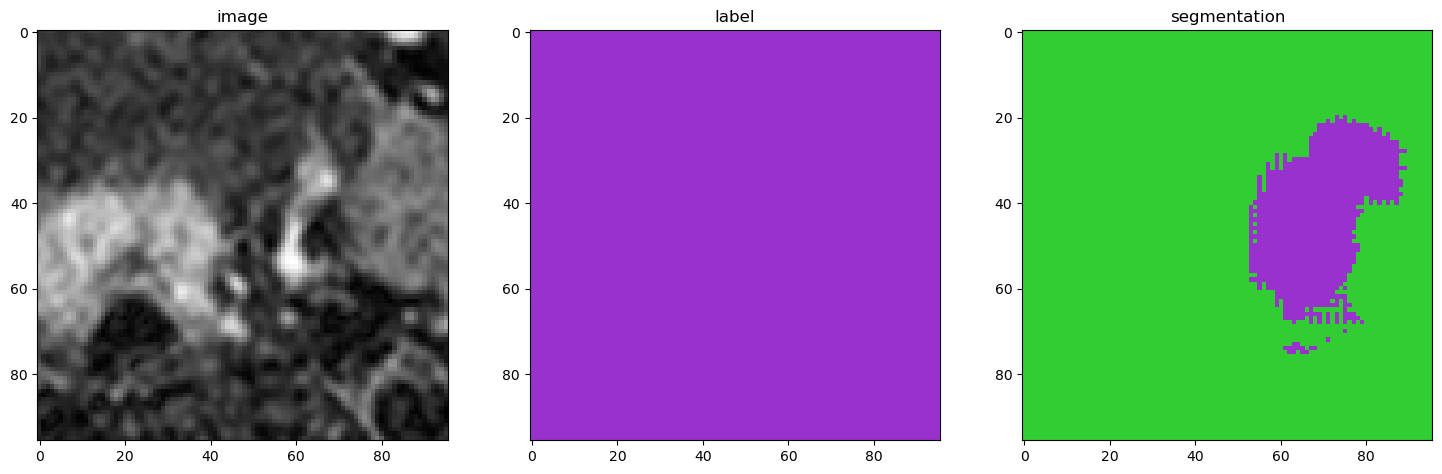

torch.Size([8, 1, 96, 96, 96])


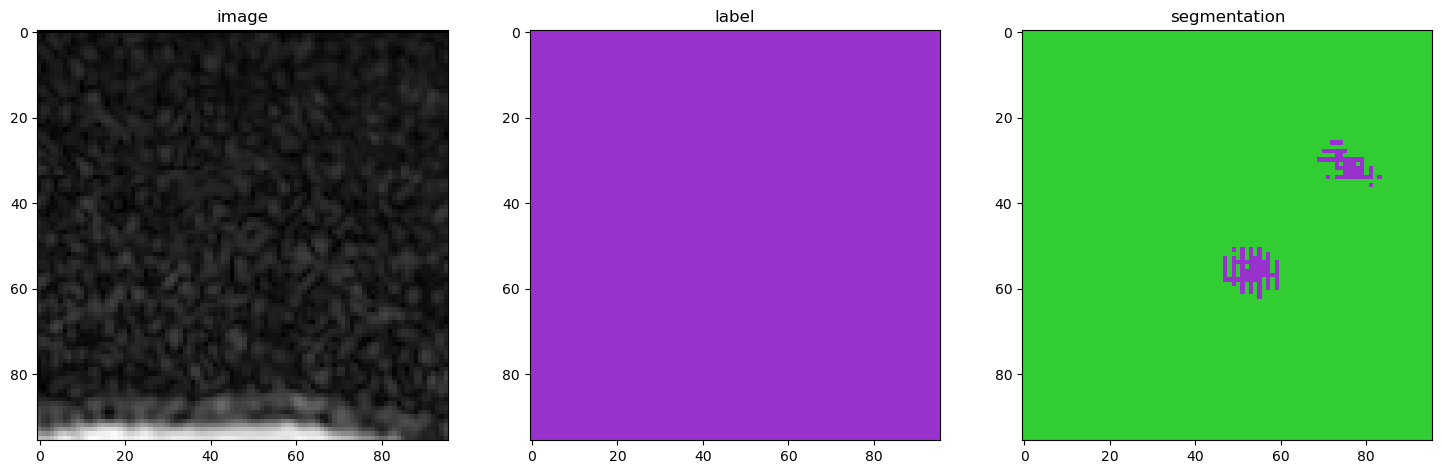

torch.Size([8, 1, 96, 96, 96])


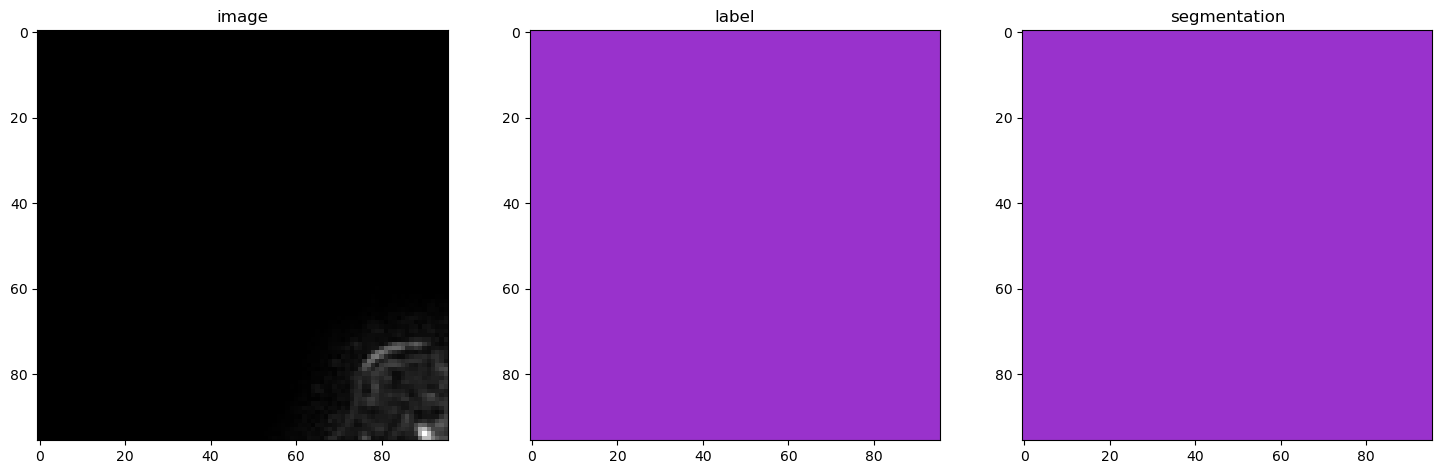

torch.Size([8, 1, 96, 96, 96])


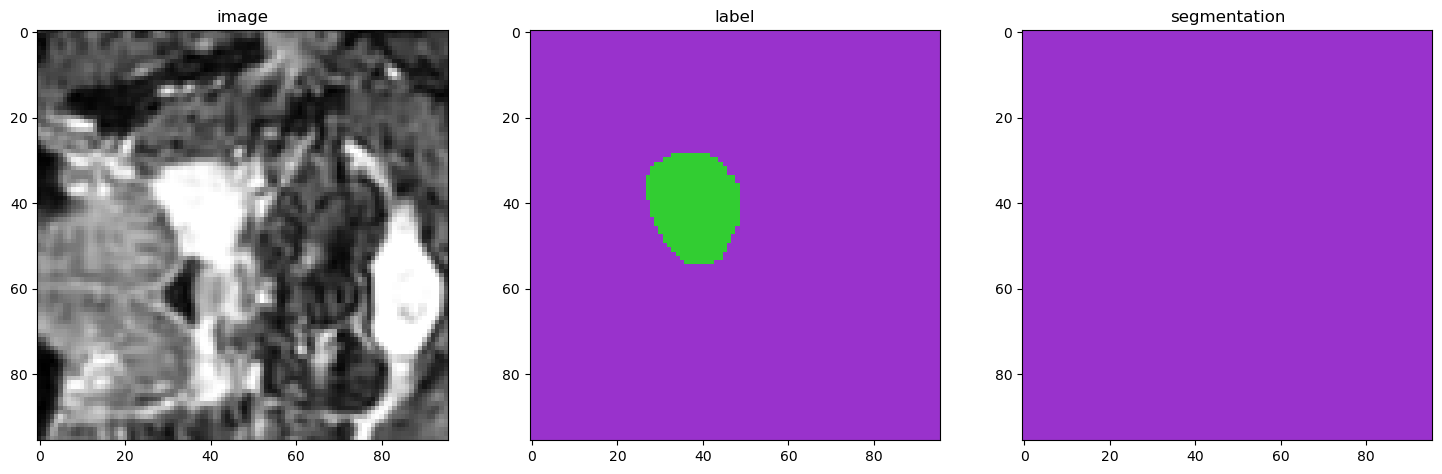

torch.Size([8, 1, 96, 96, 96])


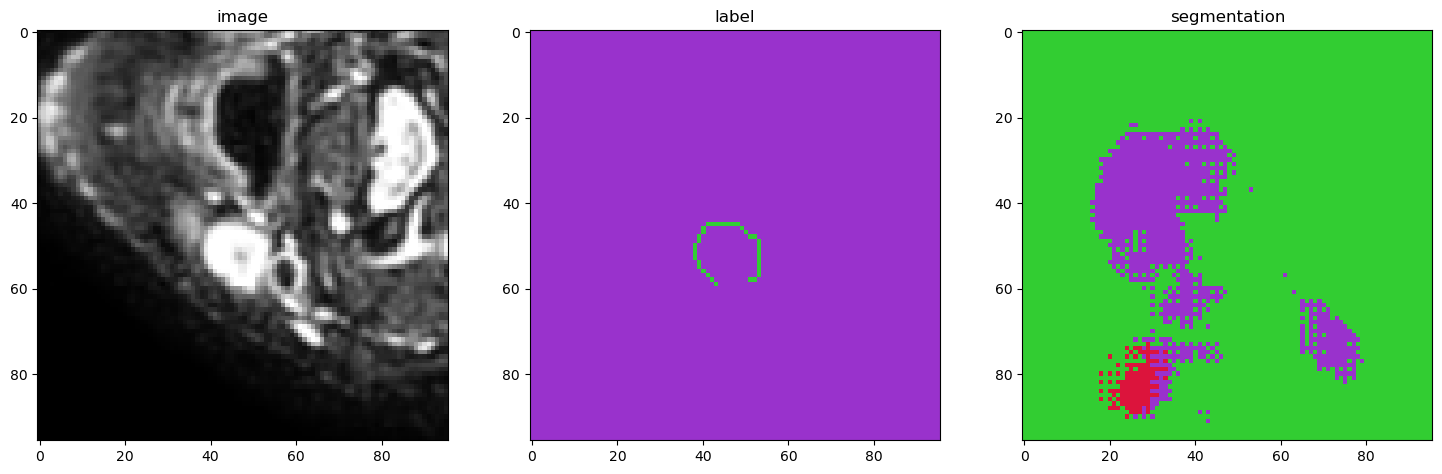

torch.Size([8, 1, 96, 96, 96])


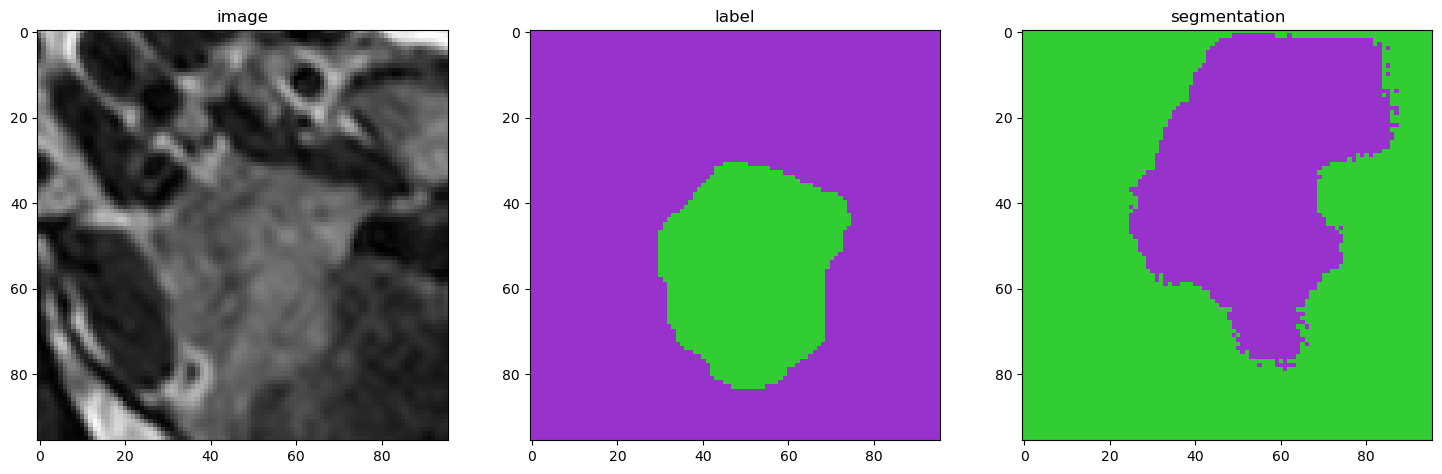

torch.Size([8, 1, 96, 96, 96])


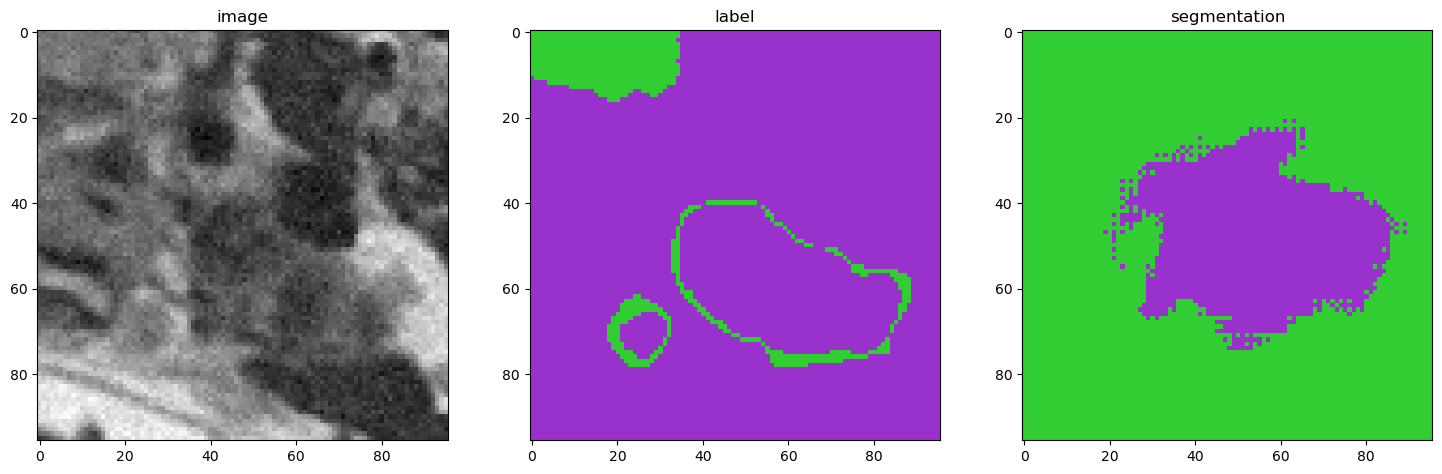

torch.Size([8, 1, 96, 96, 96])


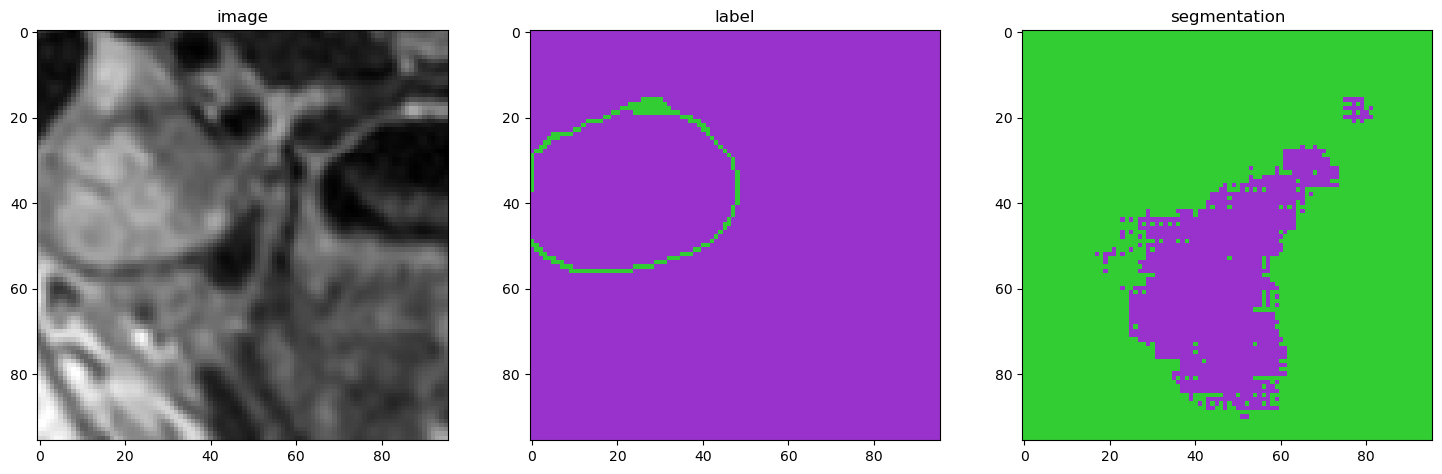

torch.Size([8, 1, 96, 96, 96])


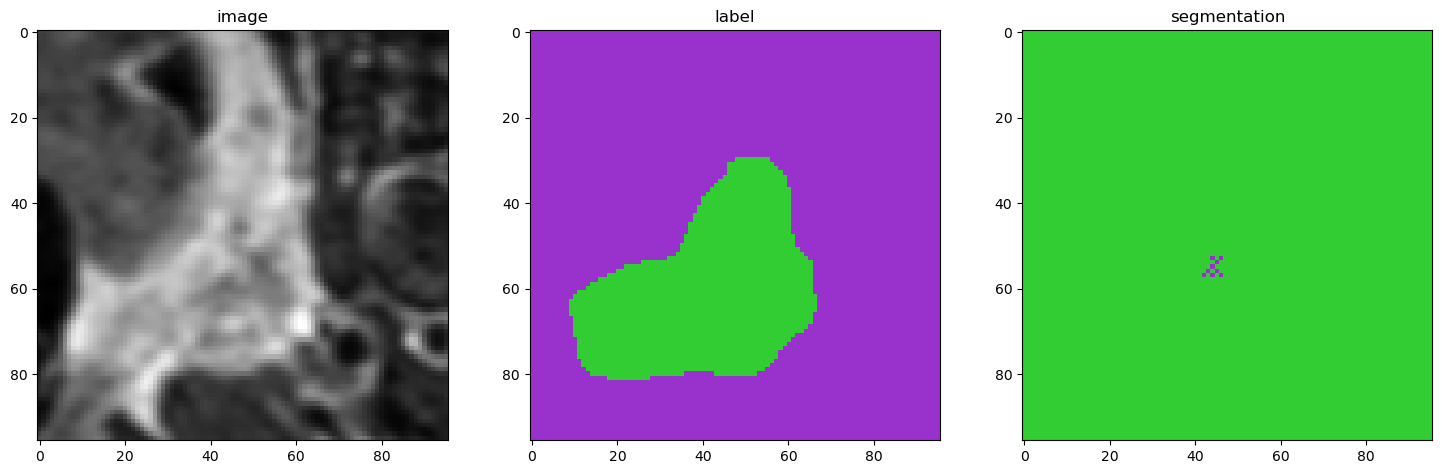

torch.Size([8, 1, 96, 96, 96])


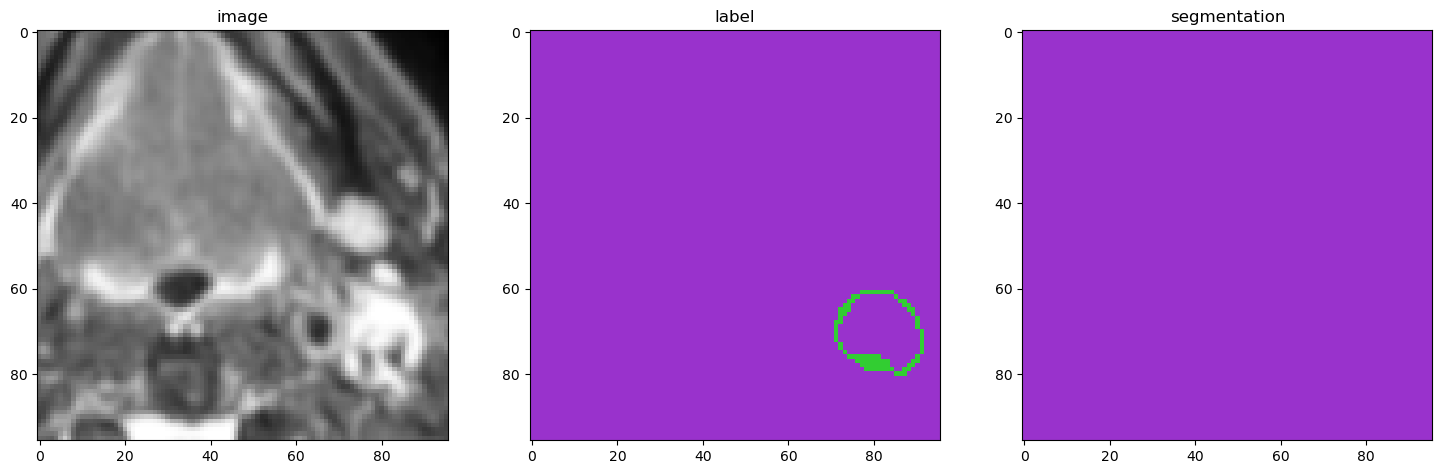

torch.Size([8, 1, 96, 96, 96])


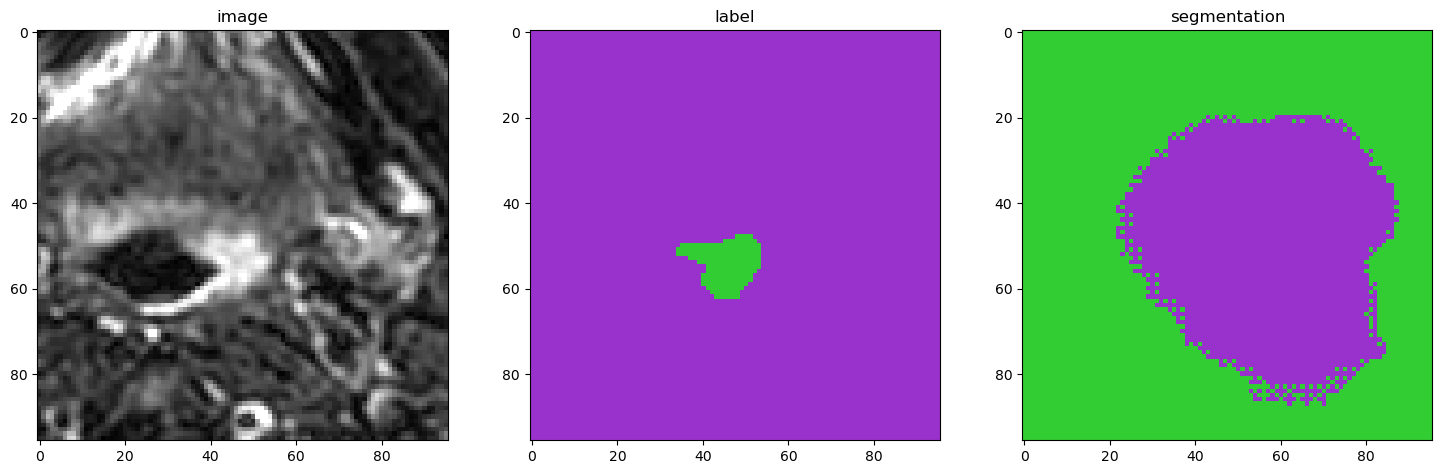

torch.Size([8, 1, 96, 96, 96])


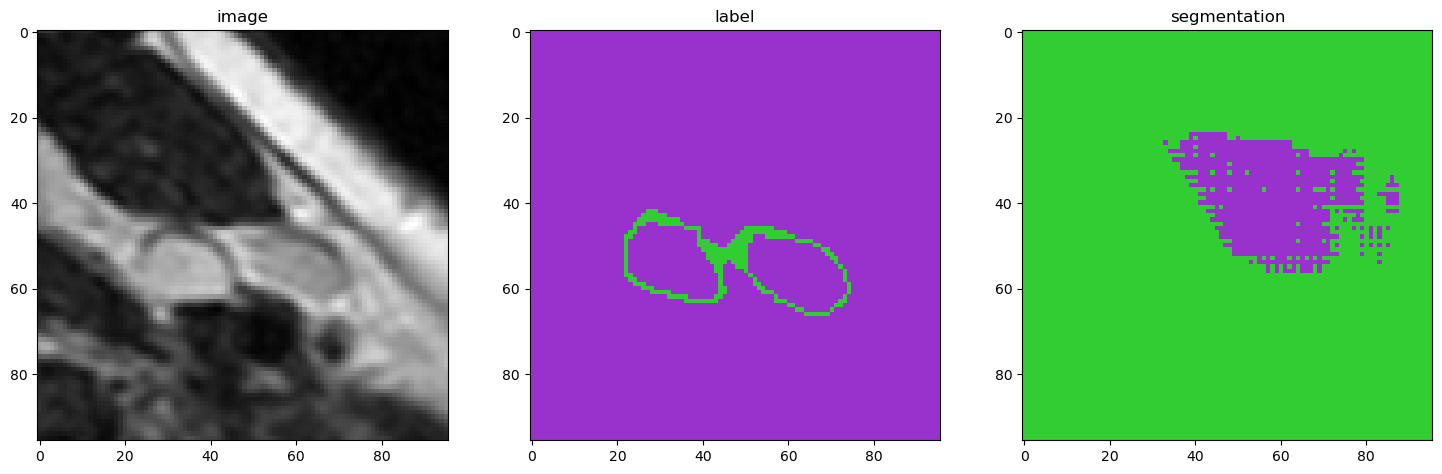

torch.Size([8, 1, 96, 96, 96])


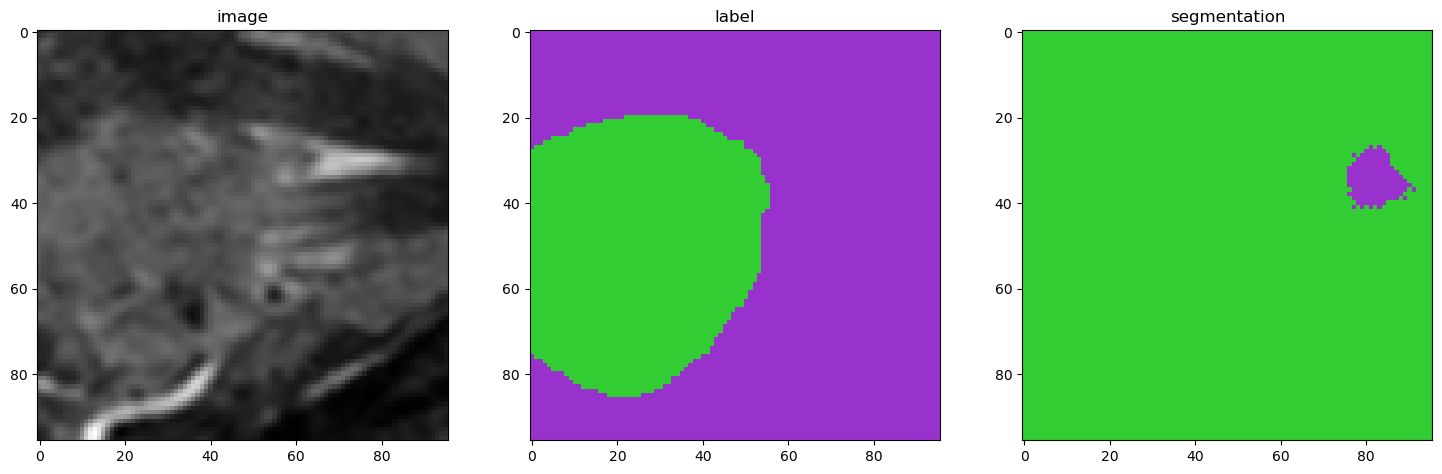

torch.Size([8, 1, 96, 96, 96])


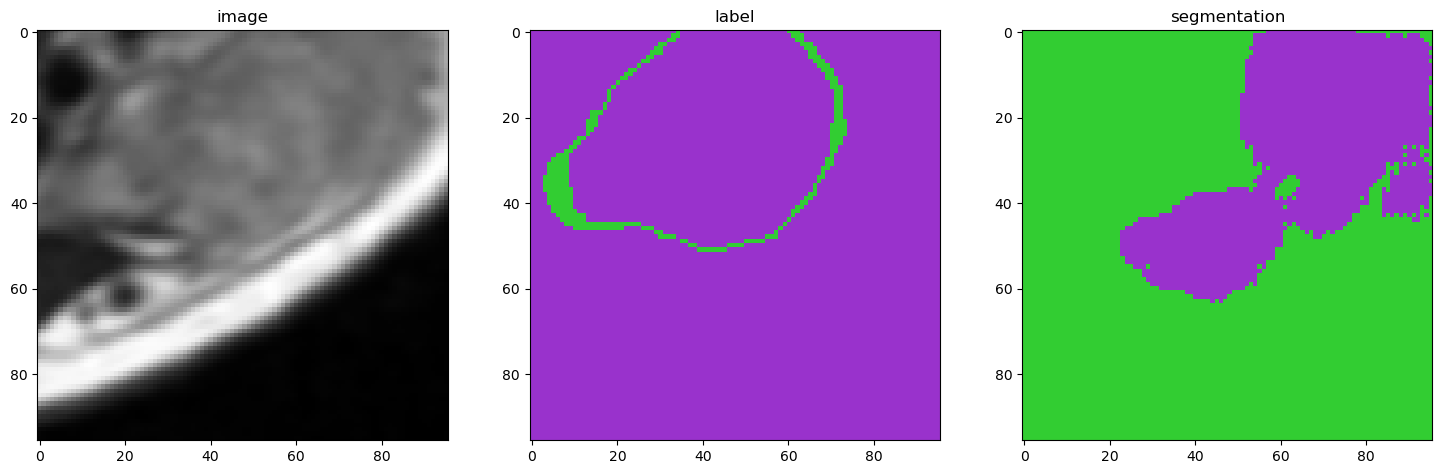

torch.Size([8, 1, 96, 96, 96])


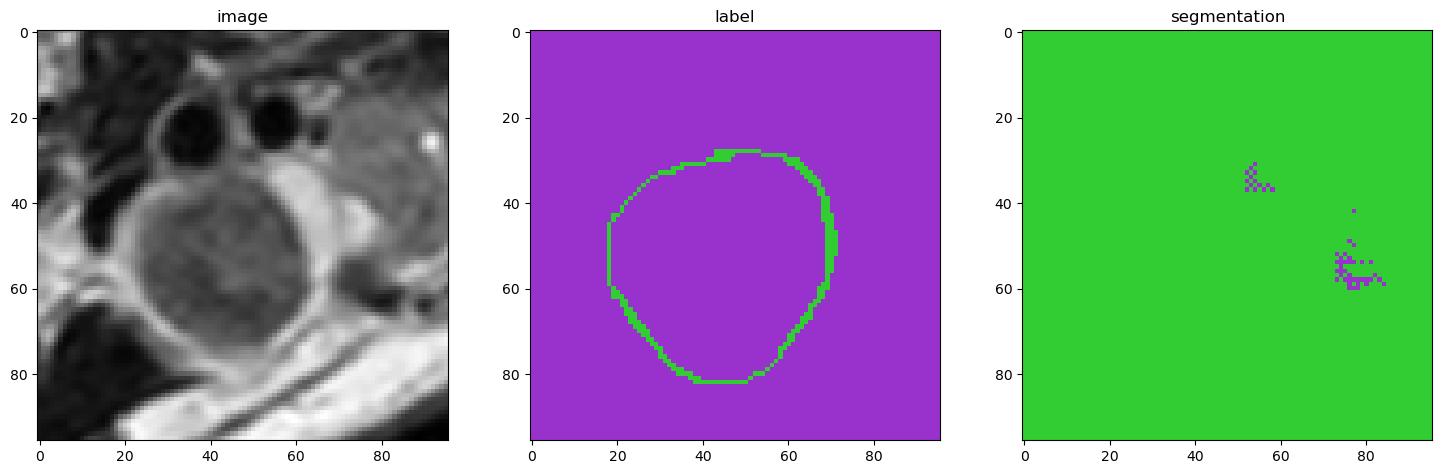

torch.Size([8, 1, 96, 96, 96])


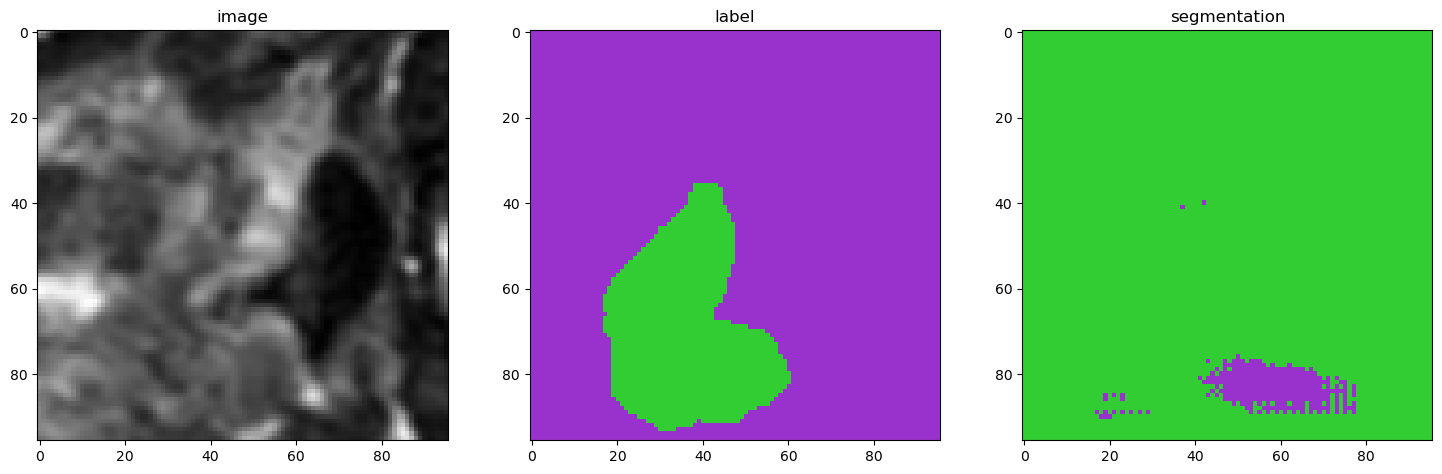

torch.Size([8, 1, 96, 96, 96])


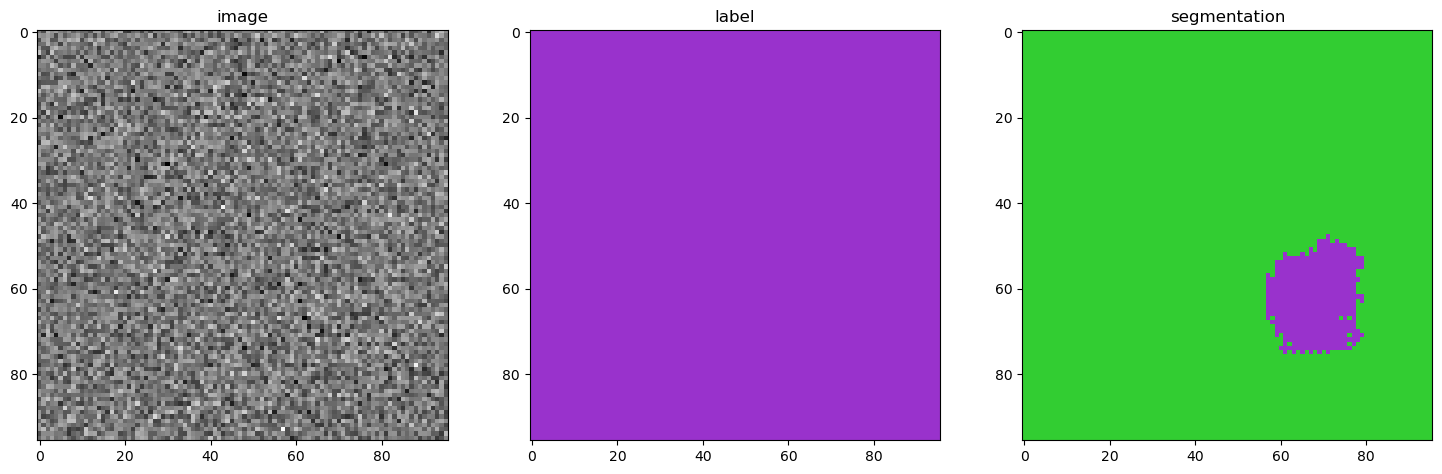

torch.Size([8, 1, 96, 96, 96])


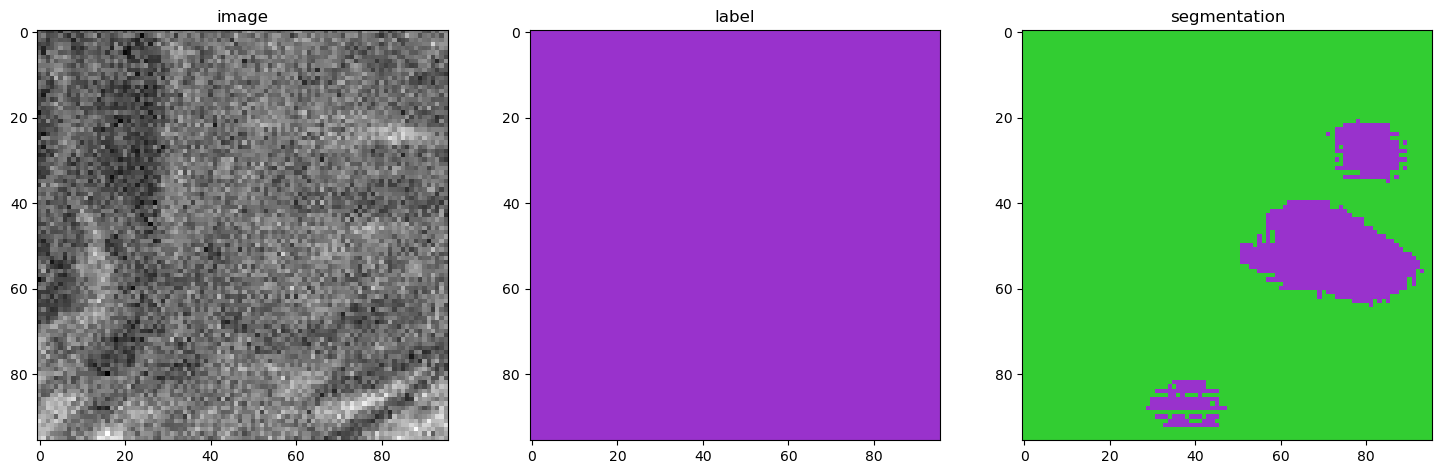

torch.Size([8, 1, 96, 96, 96])


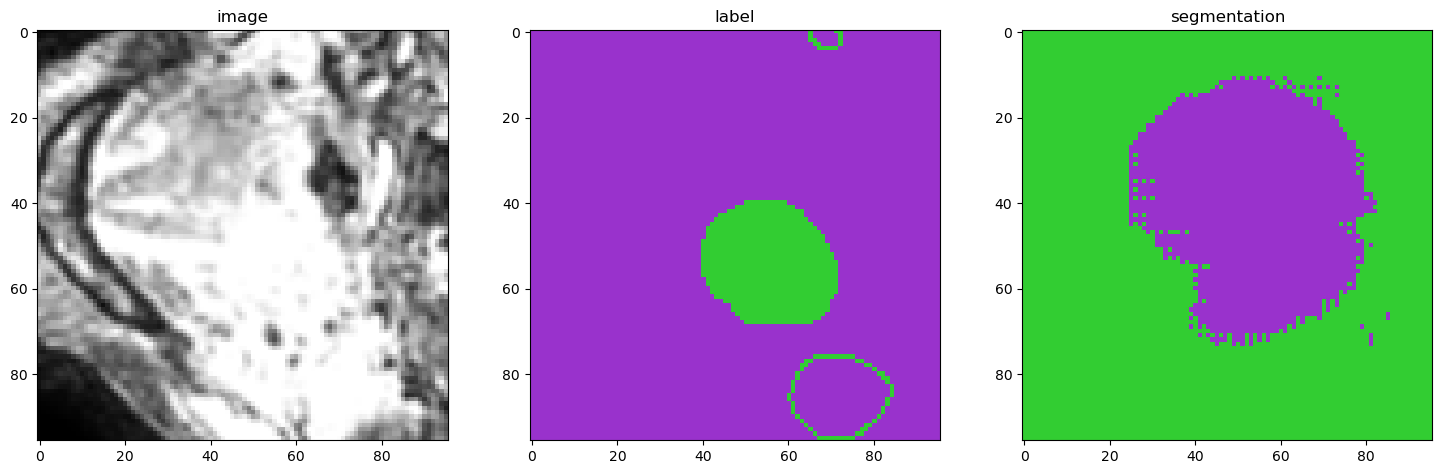

torch.Size([8, 1, 96, 96, 96])


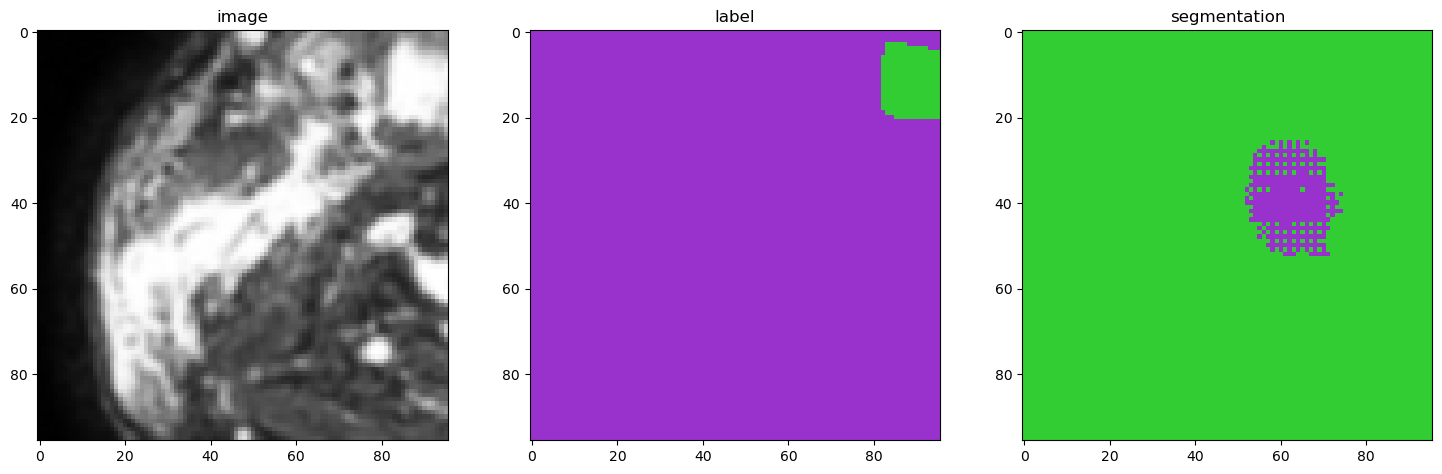

torch.Size([8, 1, 96, 96, 96])


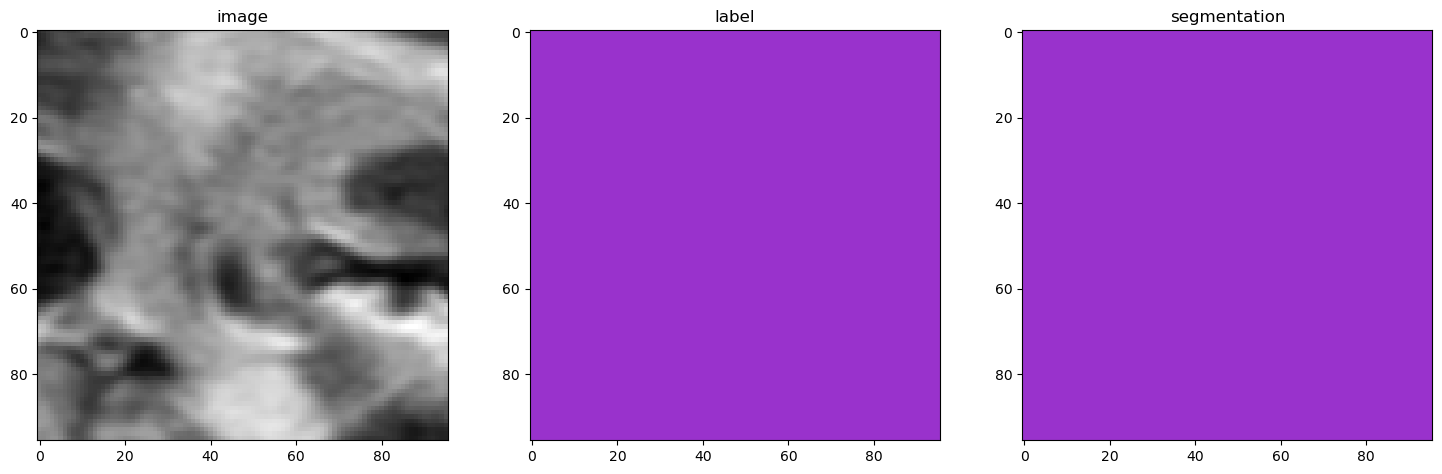

torch.Size([8, 1, 96, 96, 96])


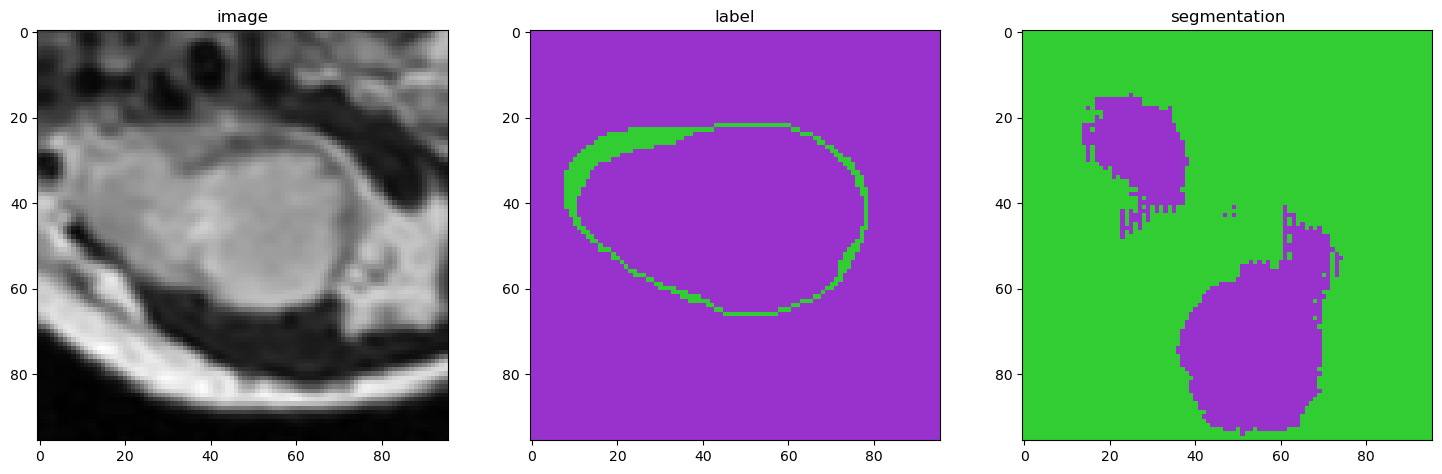

torch.Size([8, 1, 96, 96, 96])


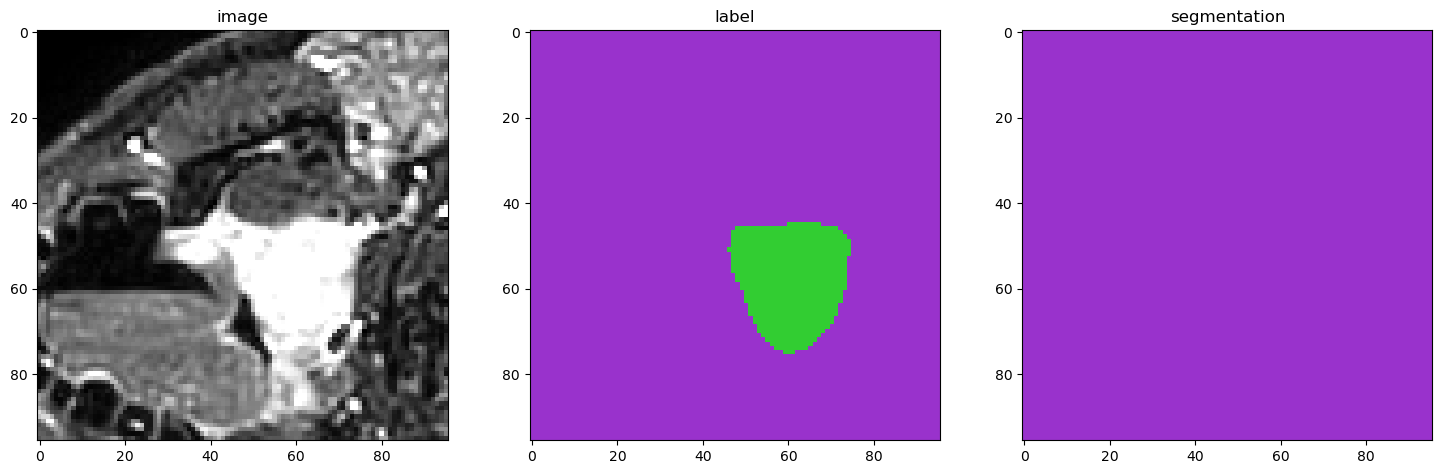

torch.Size([8, 1, 96, 96, 96])


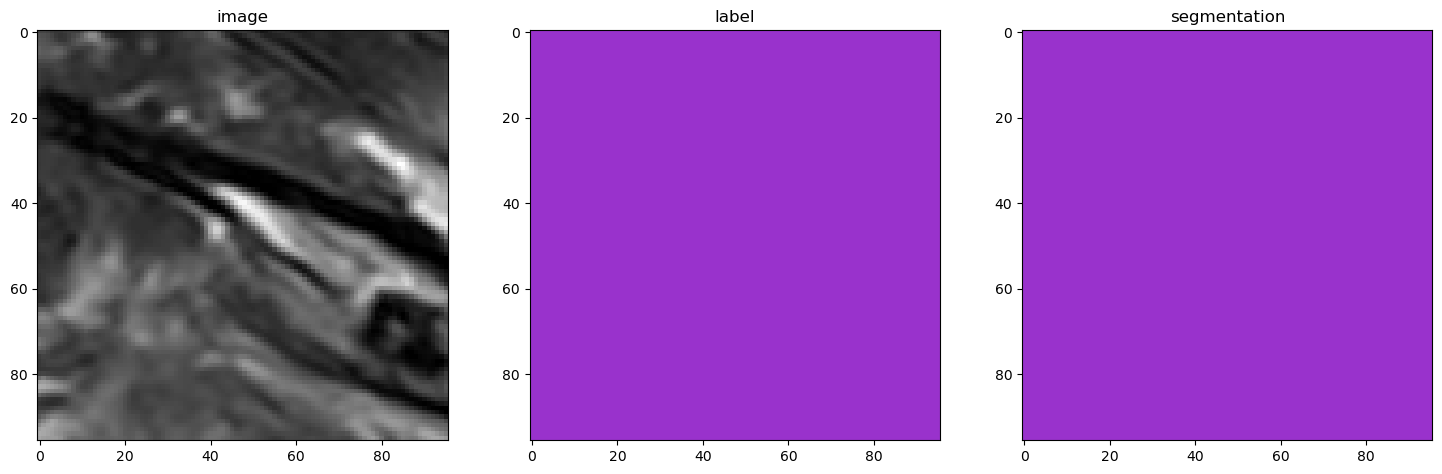

torch.Size([8, 1, 96, 96, 96])


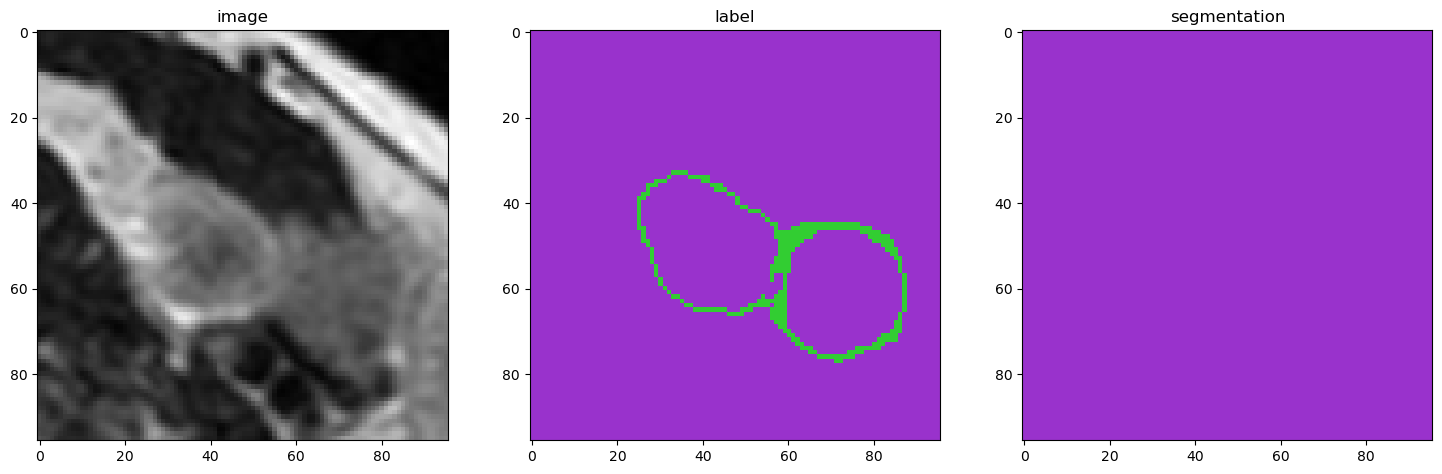

torch.Size([8, 1, 96, 96, 96])


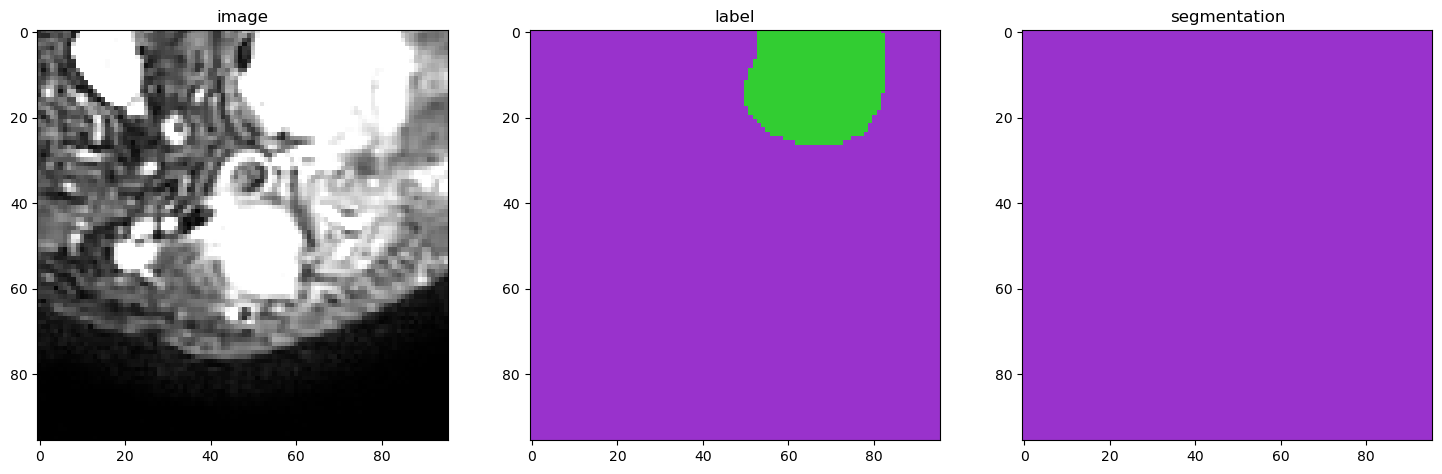

torch.Size([8, 1, 96, 96, 96])


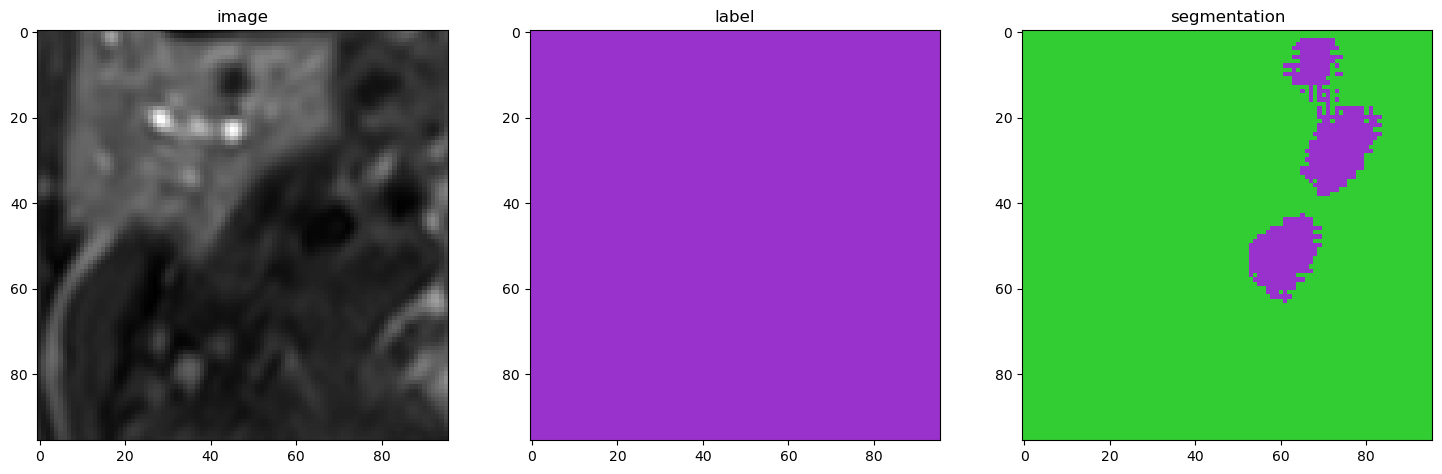

torch.Size([8, 1, 96, 96, 96])


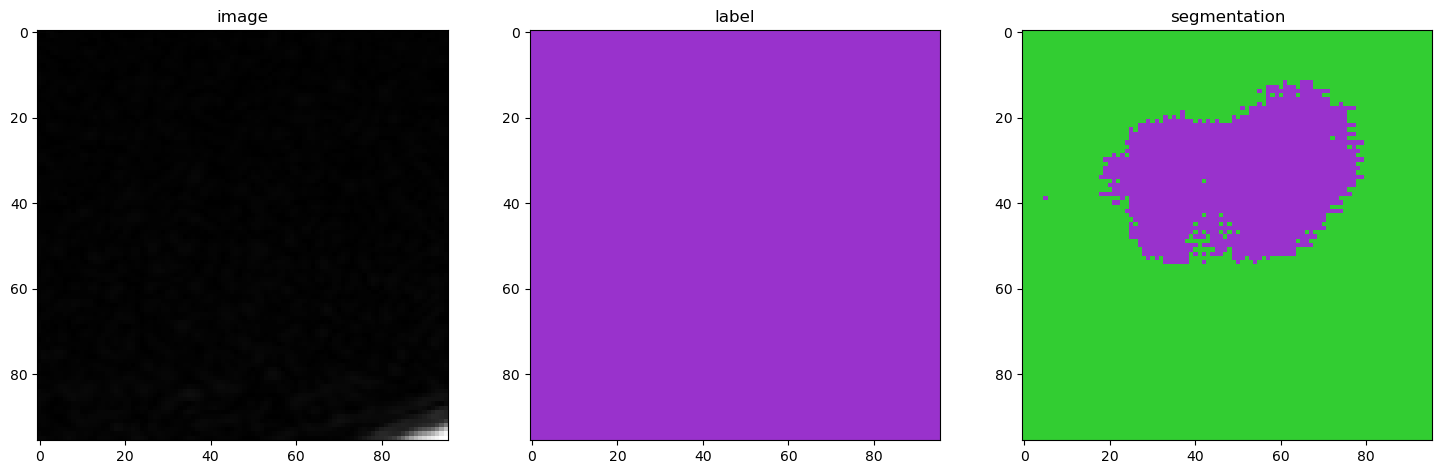

torch.Size([8, 1, 96, 96, 96])


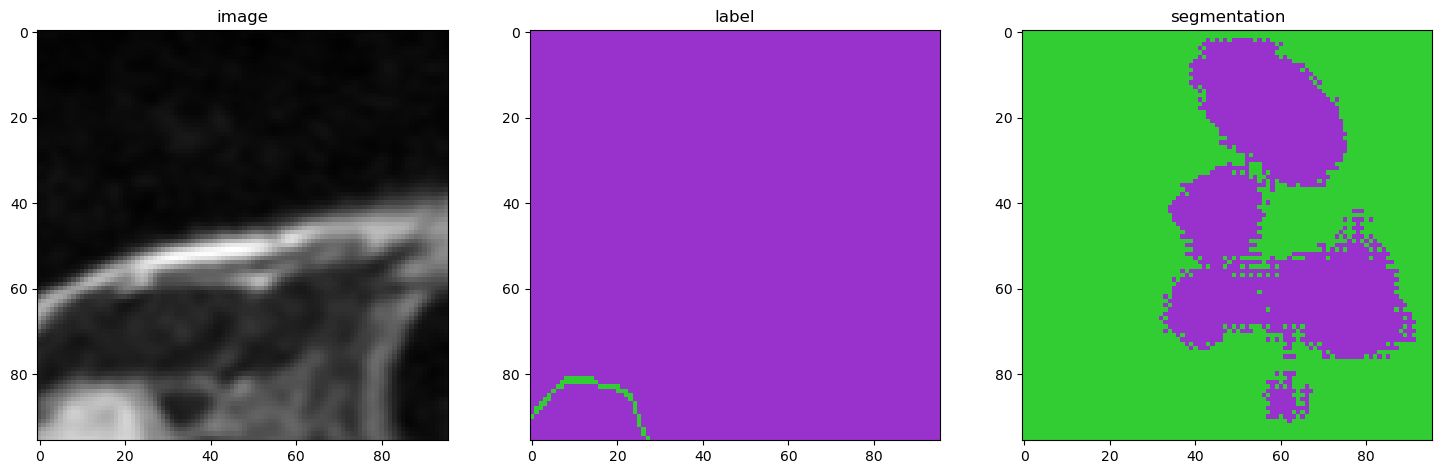

torch.Size([8, 1, 96, 96, 96])


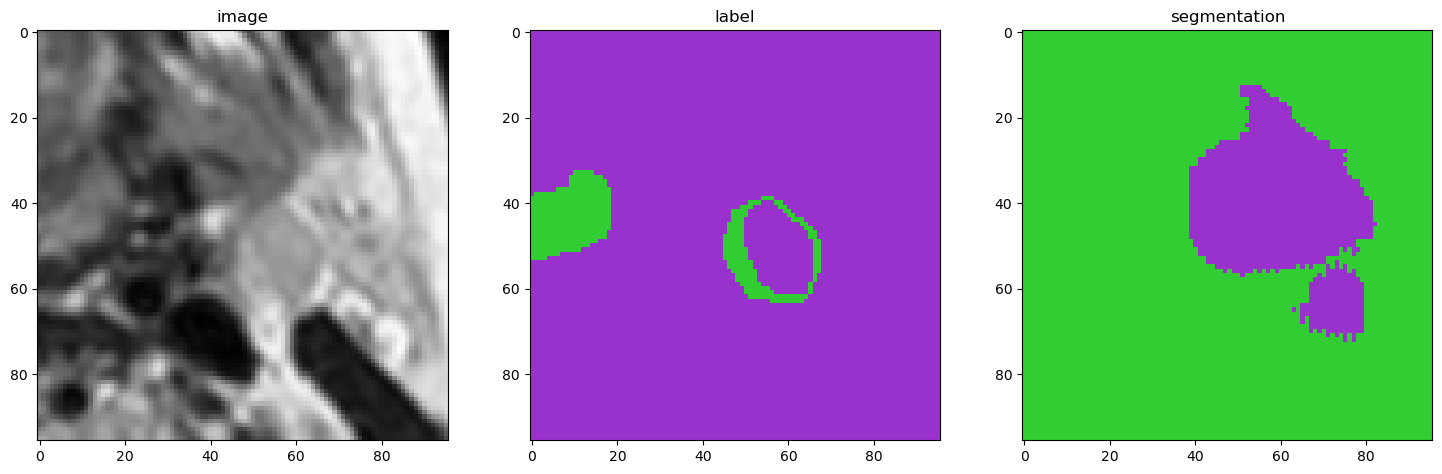

torch.Size([8, 1, 96, 96, 96])


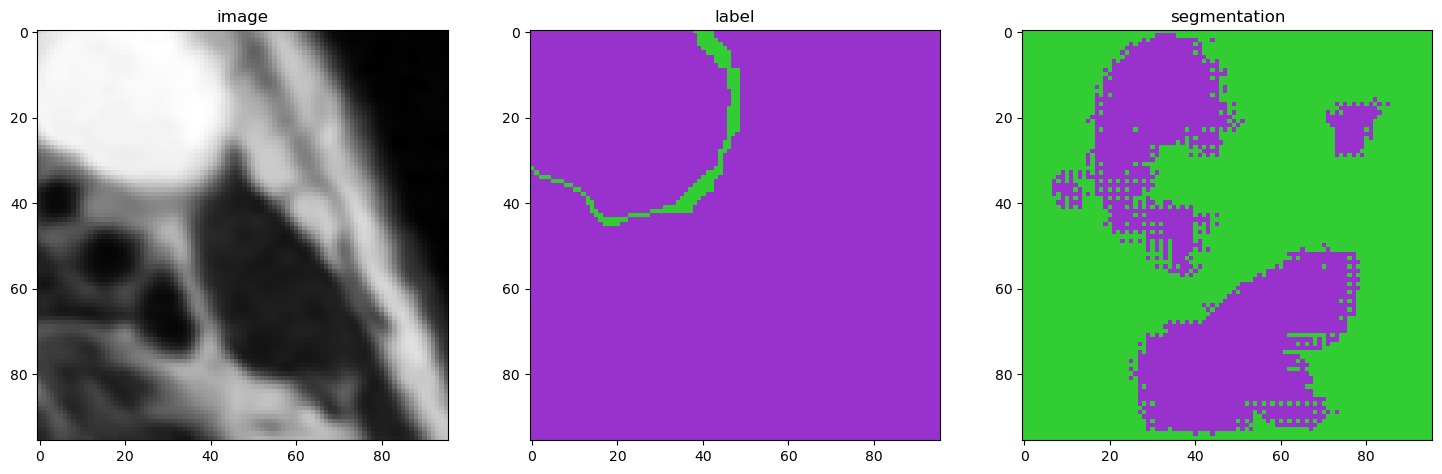

torch.Size([8, 1, 96, 96, 96])


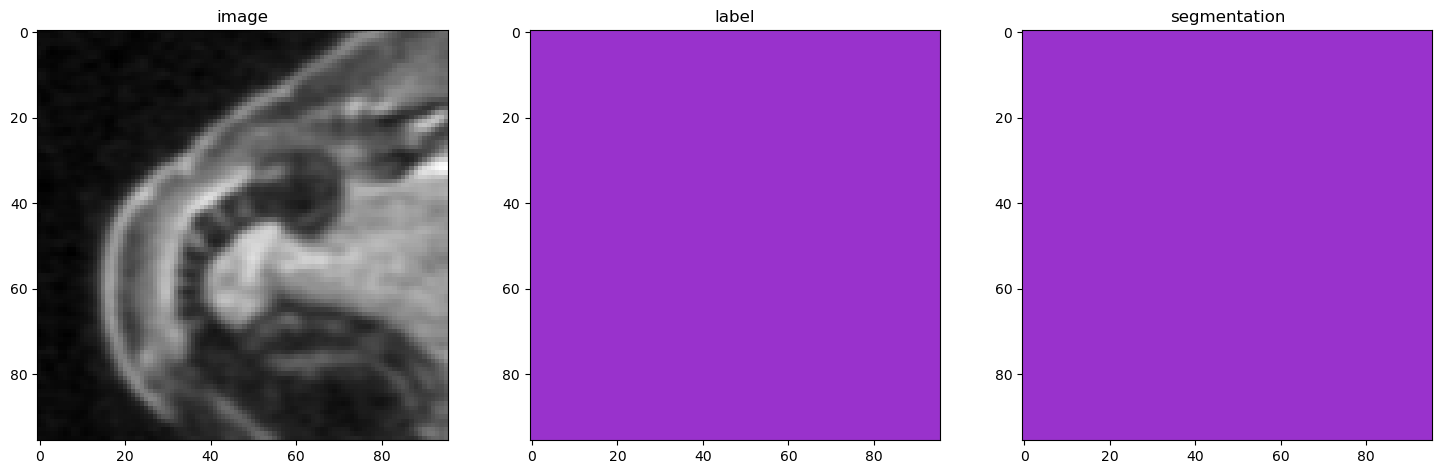

torch.Size([8, 1, 96, 96, 96])


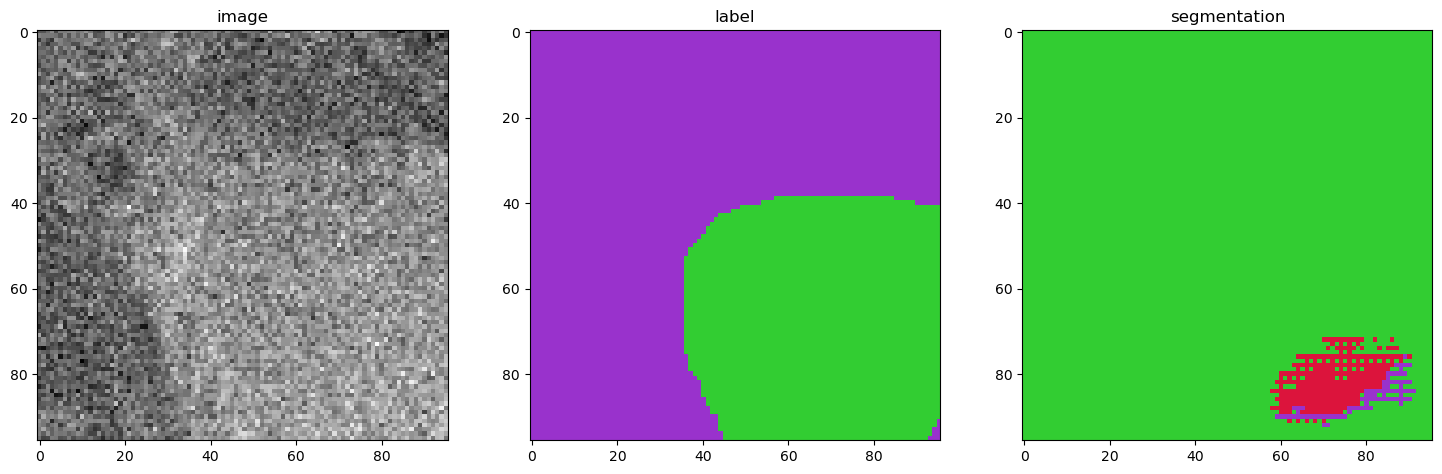

torch.Size([8, 1, 96, 96, 96])


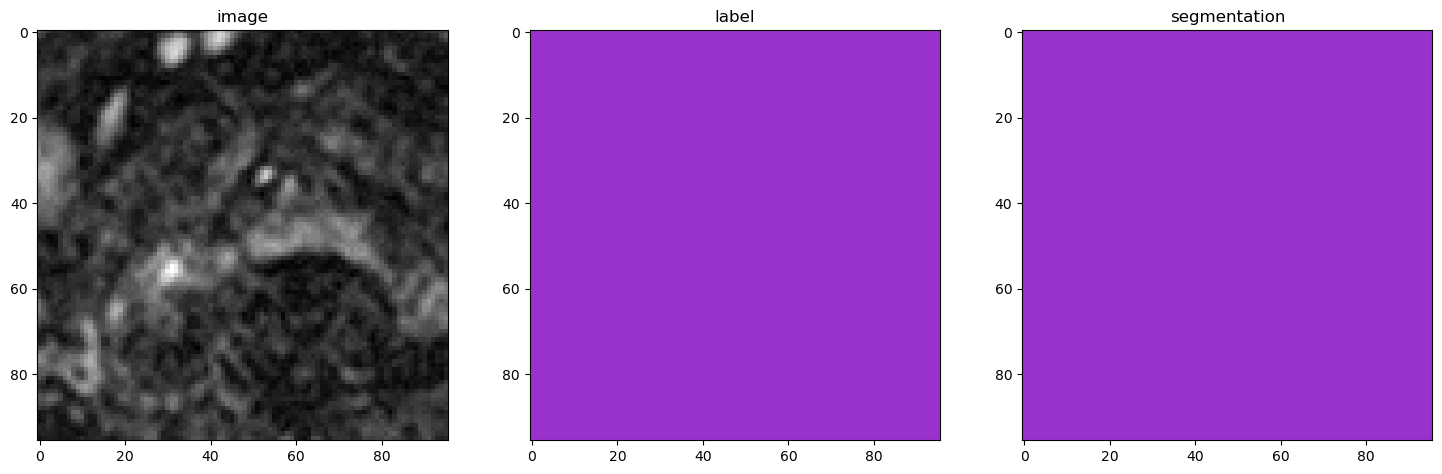

torch.Size([8, 1, 96, 96, 96])


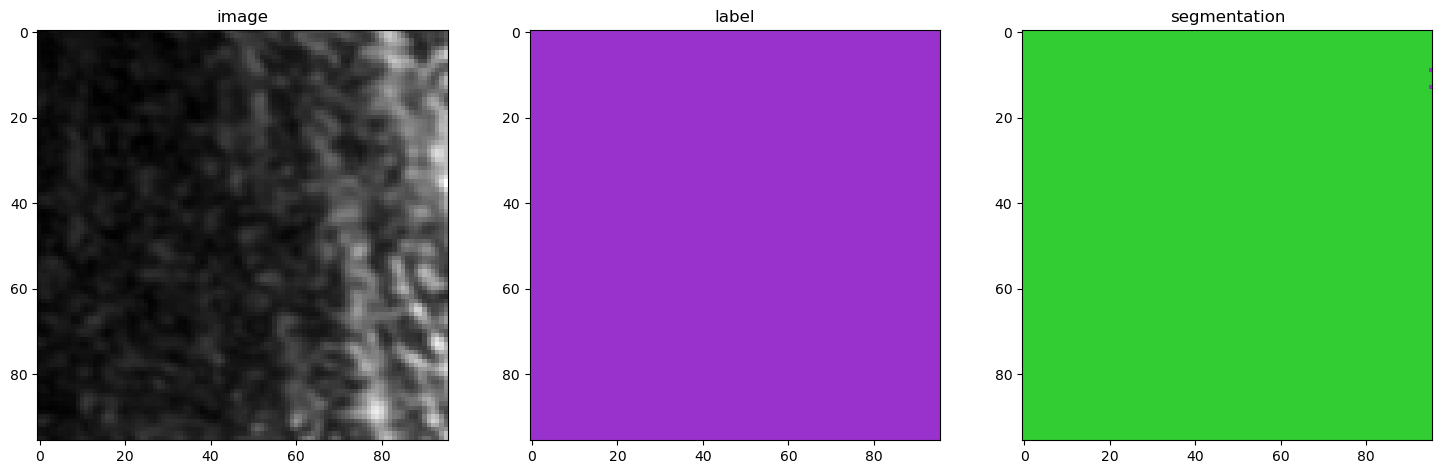

torch.Size([8, 1, 96, 96, 96])


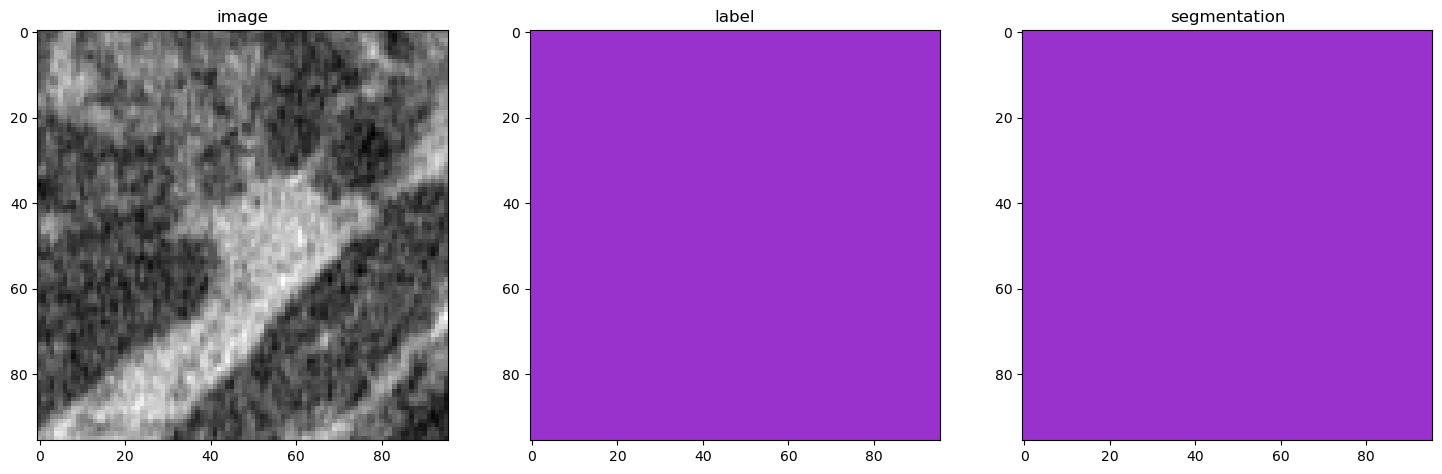

torch.Size([8, 1, 96, 96, 96])


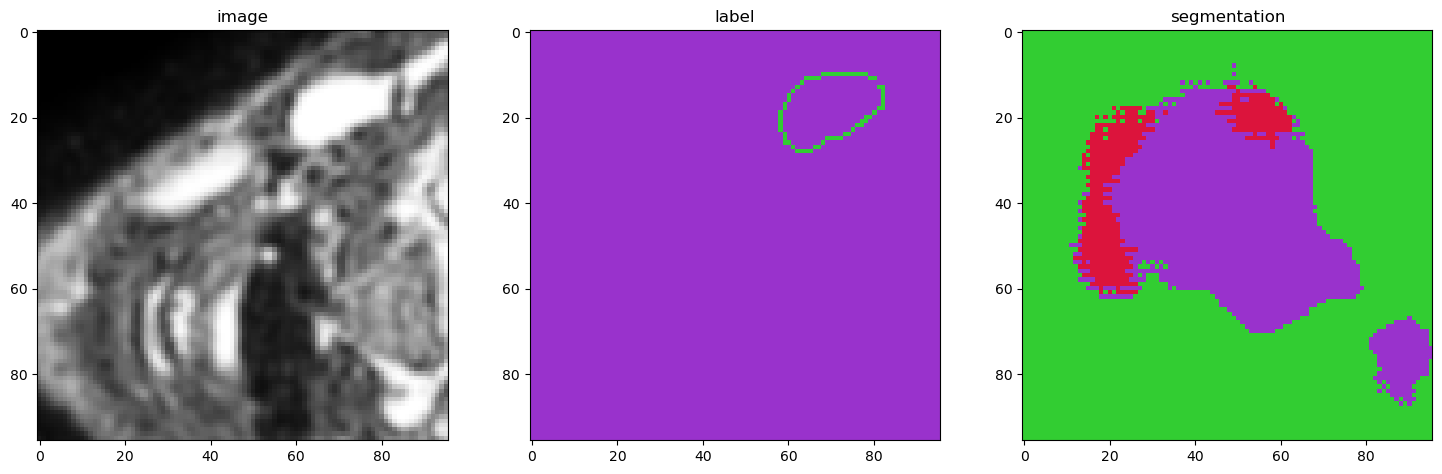

torch.Size([8, 1, 96, 96, 96])


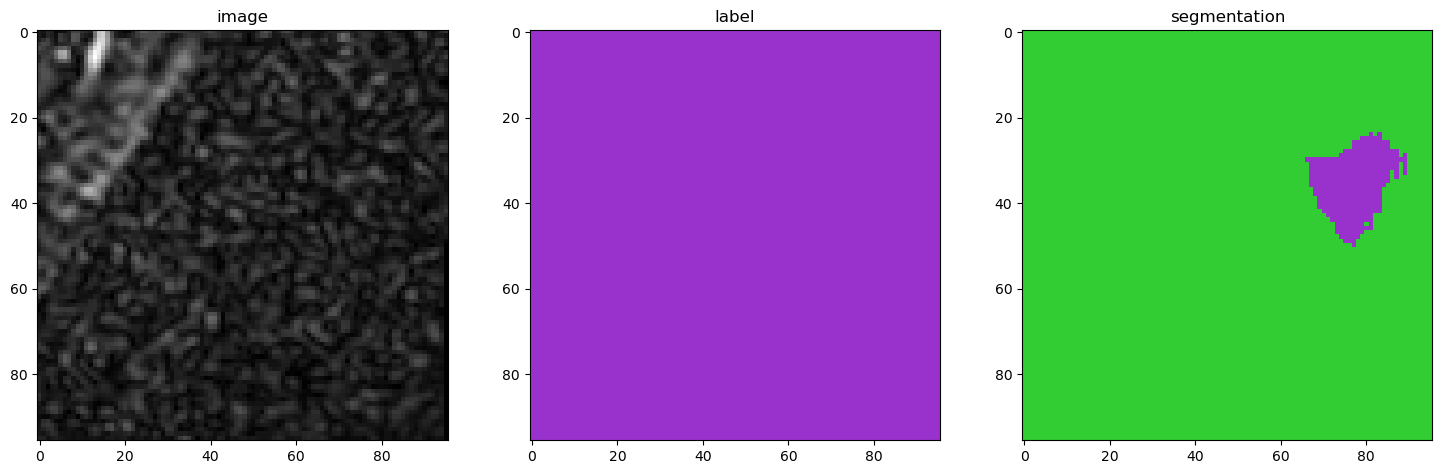

torch.Size([8, 1, 96, 96, 96])


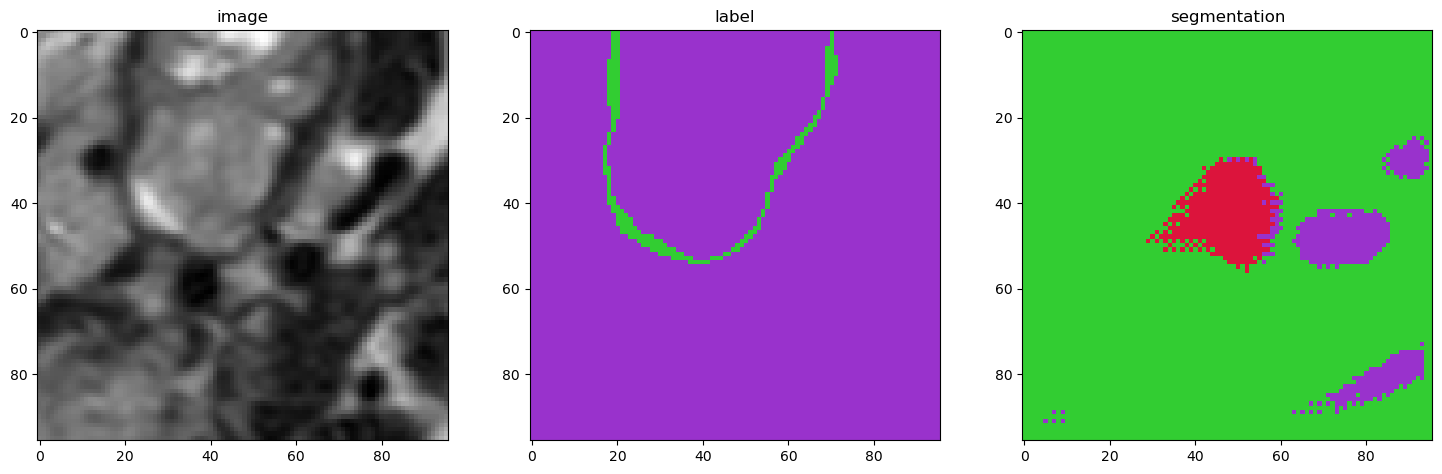

torch.Size([8, 1, 96, 96, 96])


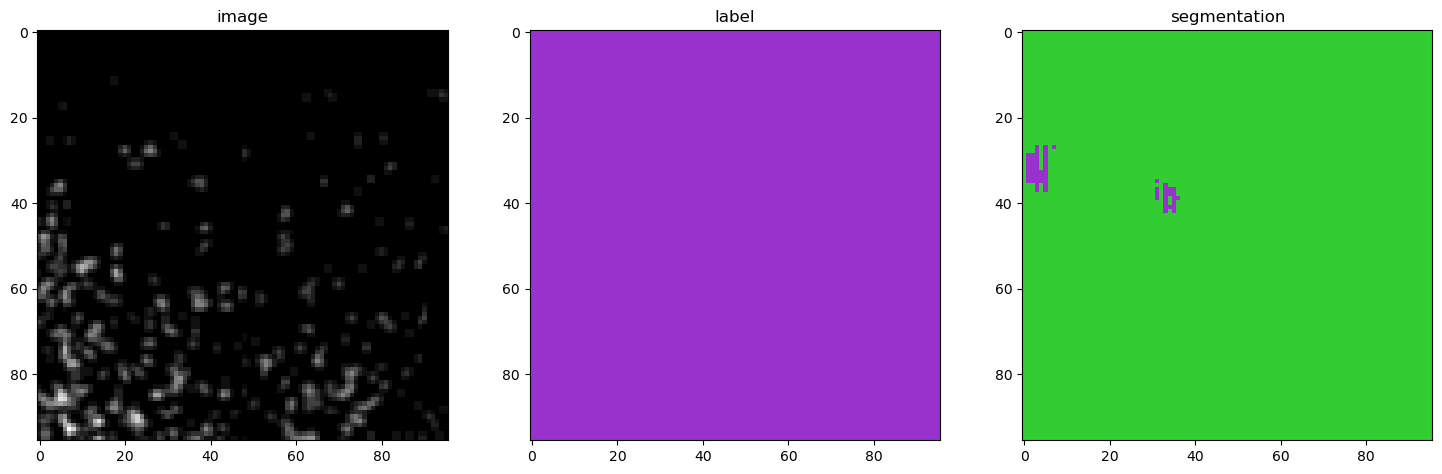

torch.Size([8, 1, 96, 96, 96])


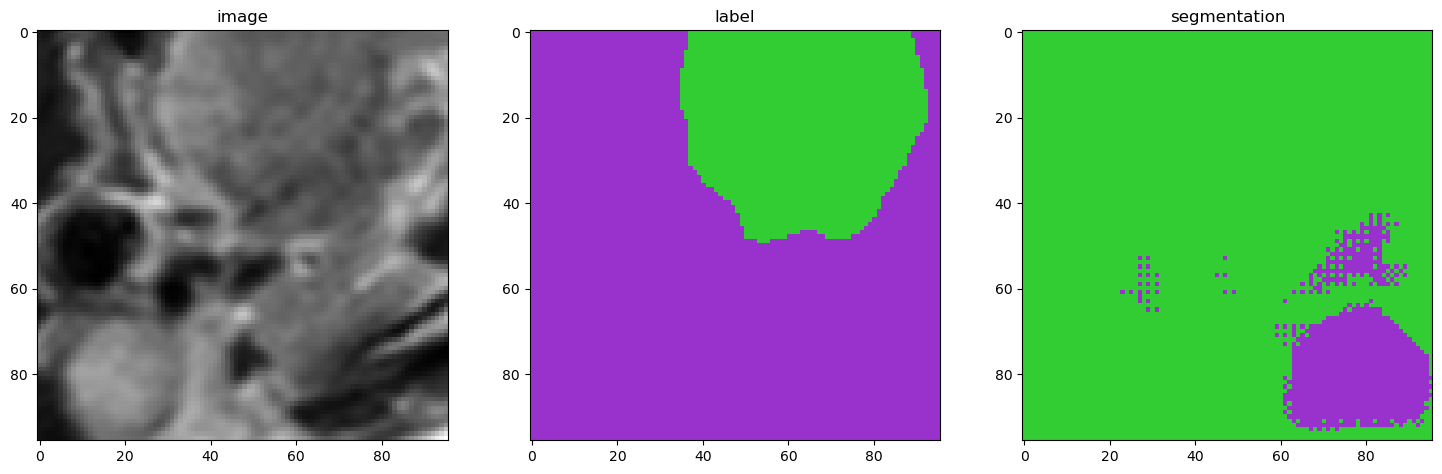

torch.Size([8, 1, 96, 96, 96])


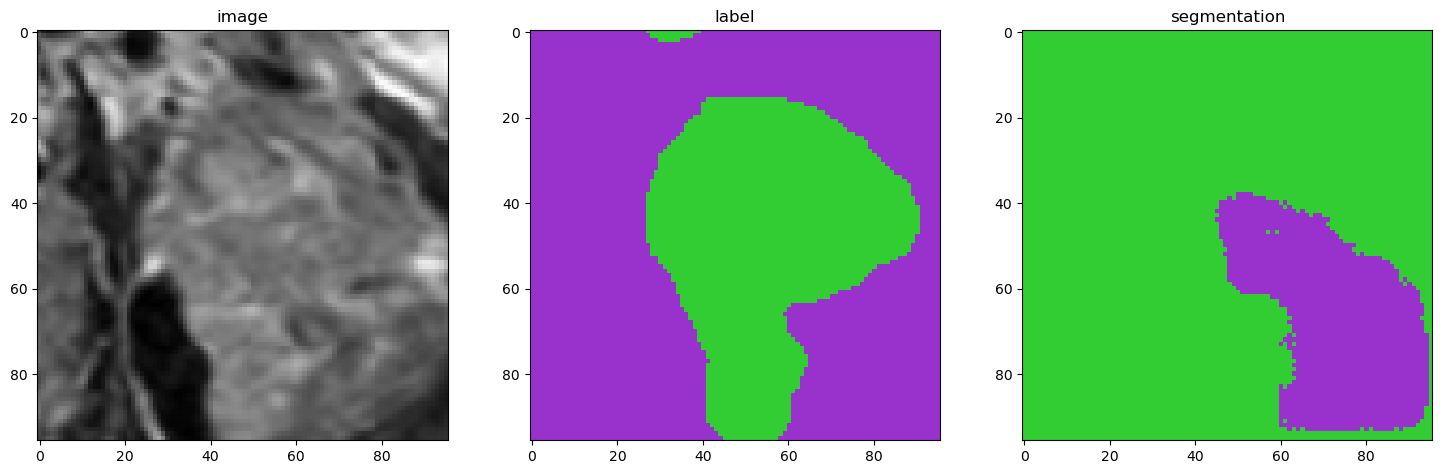

torch.Size([8, 1, 96, 96, 96])


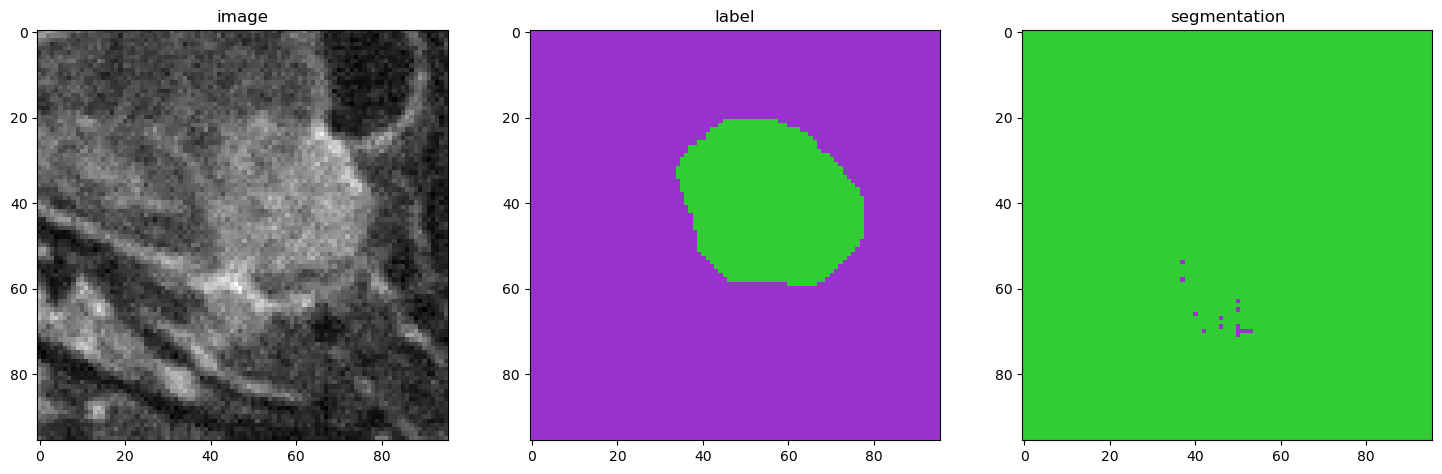

torch.Size([8, 1, 96, 96, 96])


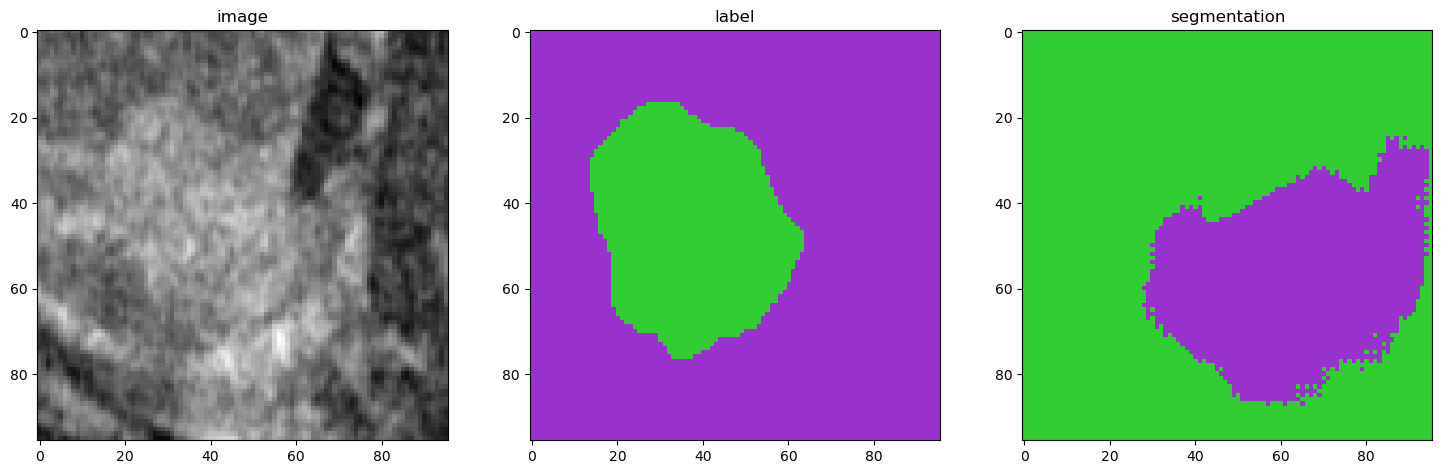

torch.Size([8, 1, 96, 96, 96])


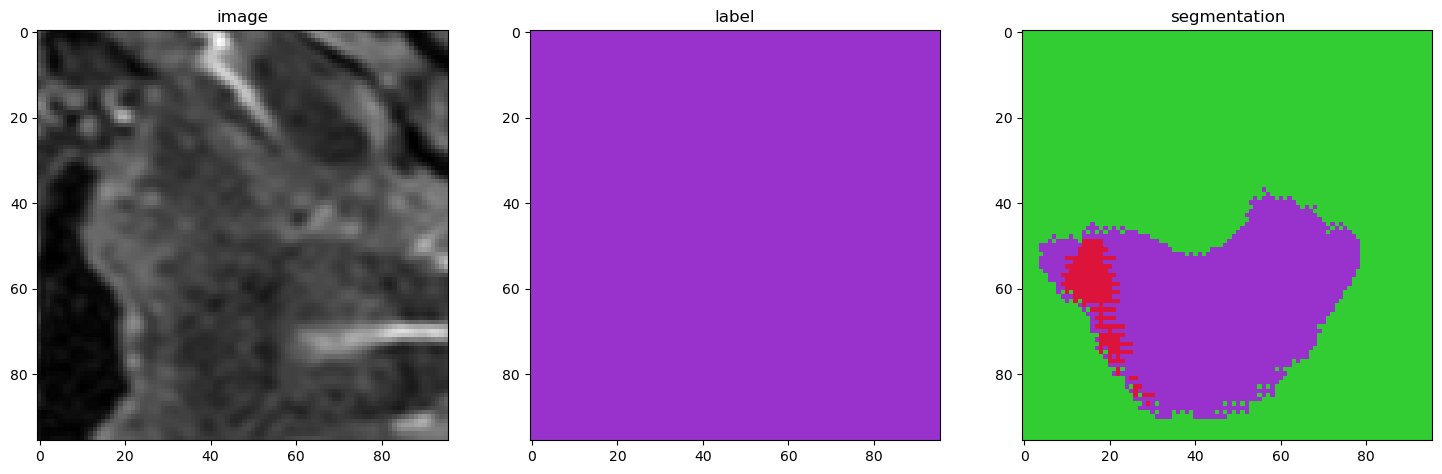

torch.Size([8, 1, 96, 96, 96])


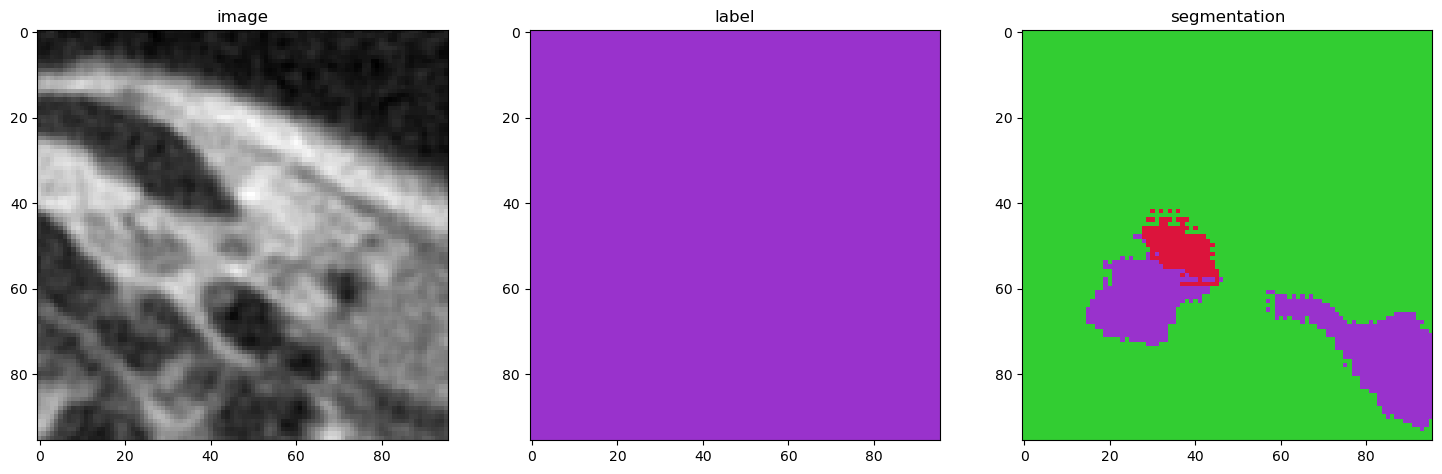

torch.Size([8, 1, 96, 96, 96])


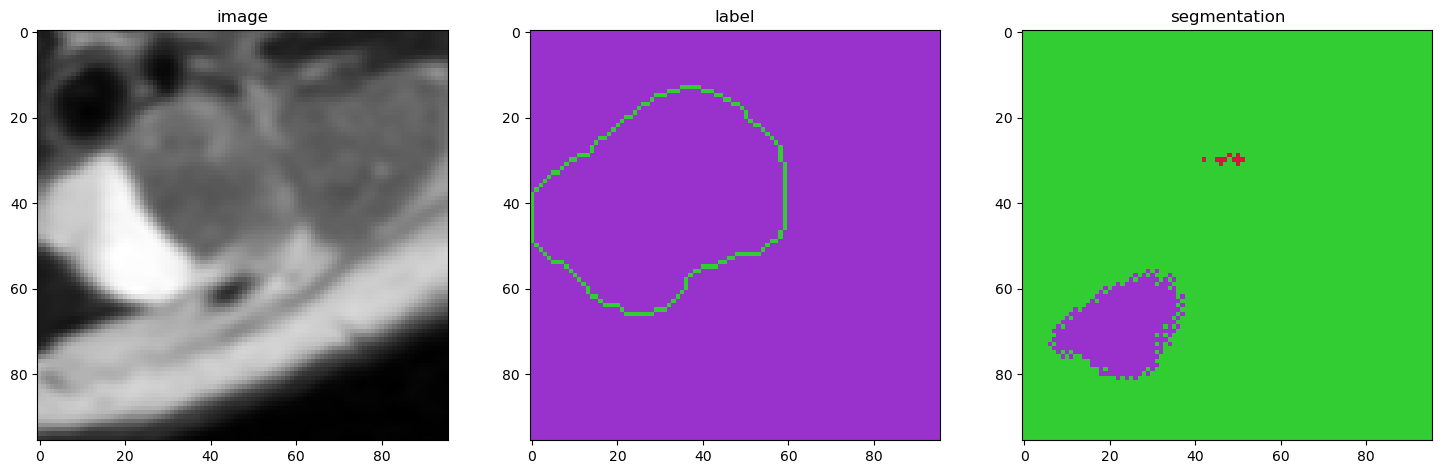

torch.Size([8, 1, 96, 96, 96])


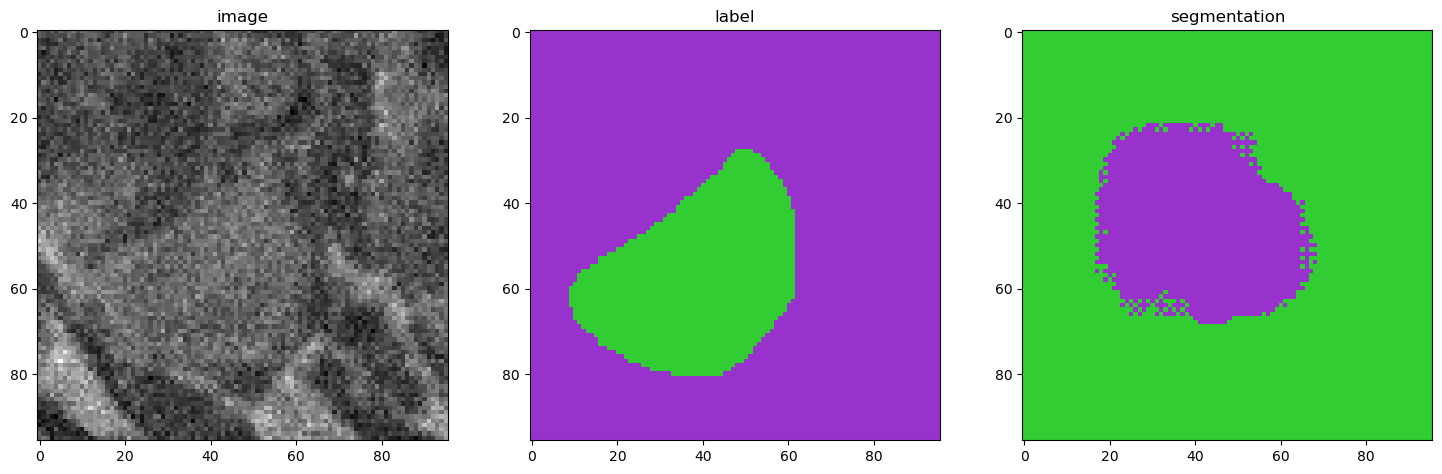

torch.Size([8, 1, 96, 96, 96])


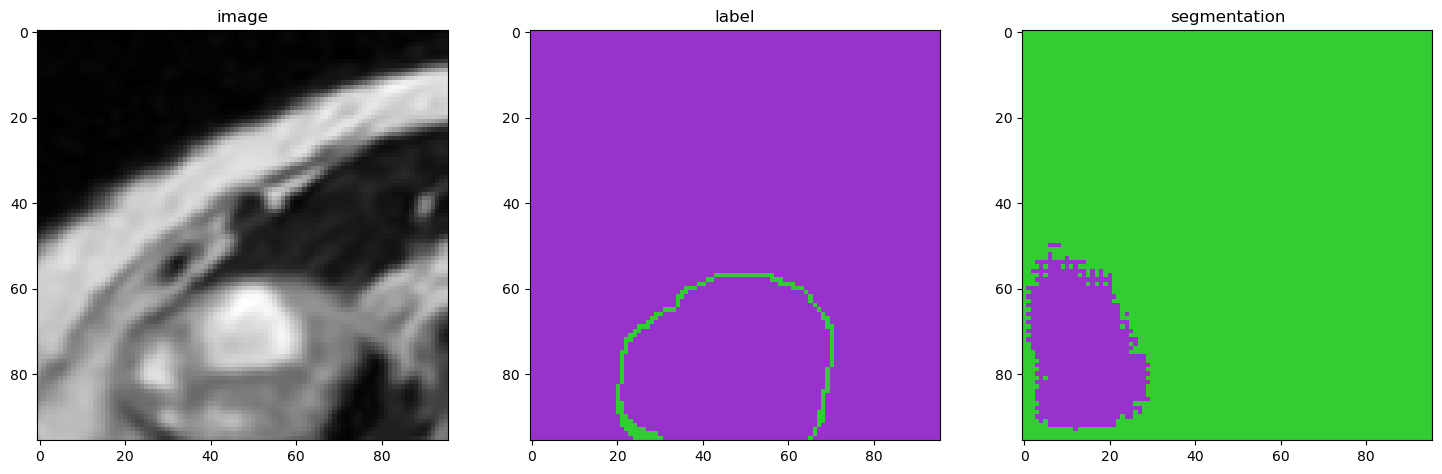

torch.Size([8, 1, 96, 96, 96])


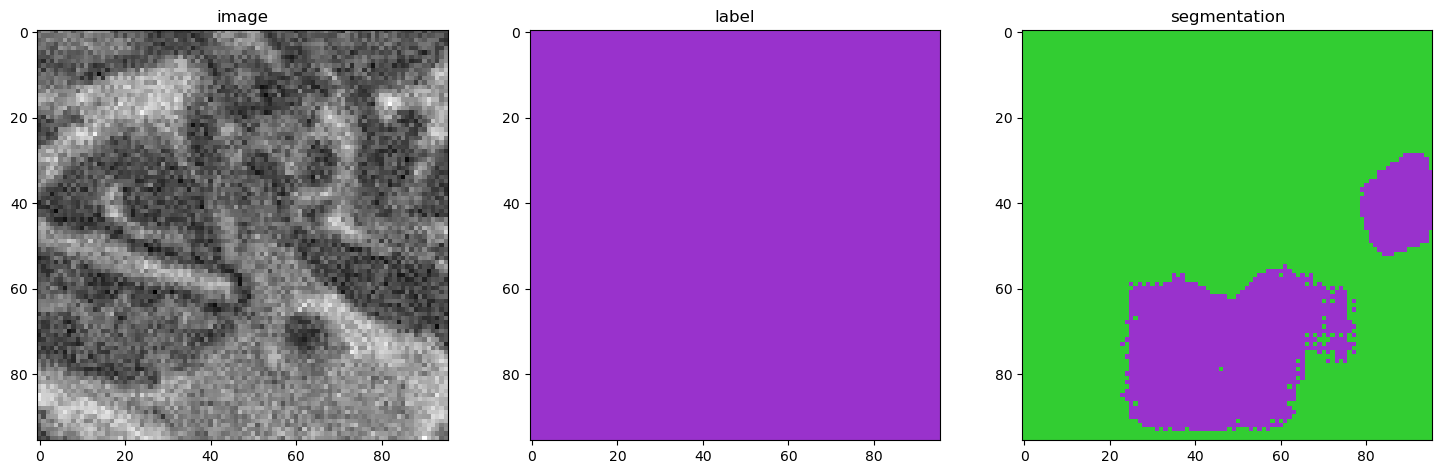

torch.Size([8, 1, 96, 96, 96])


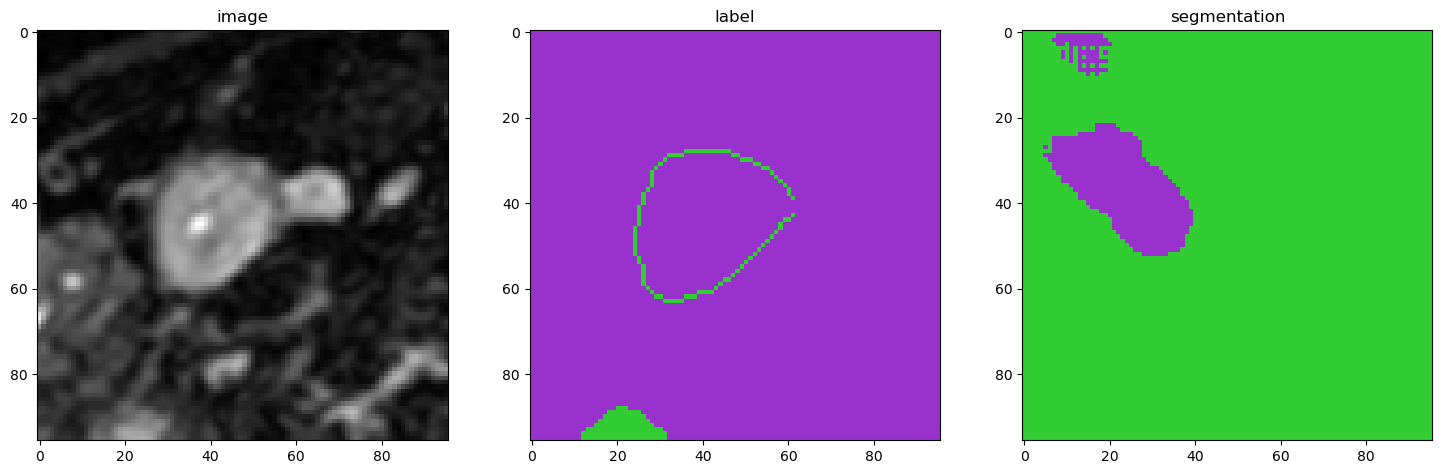

torch.Size([8, 1, 96, 96, 96])


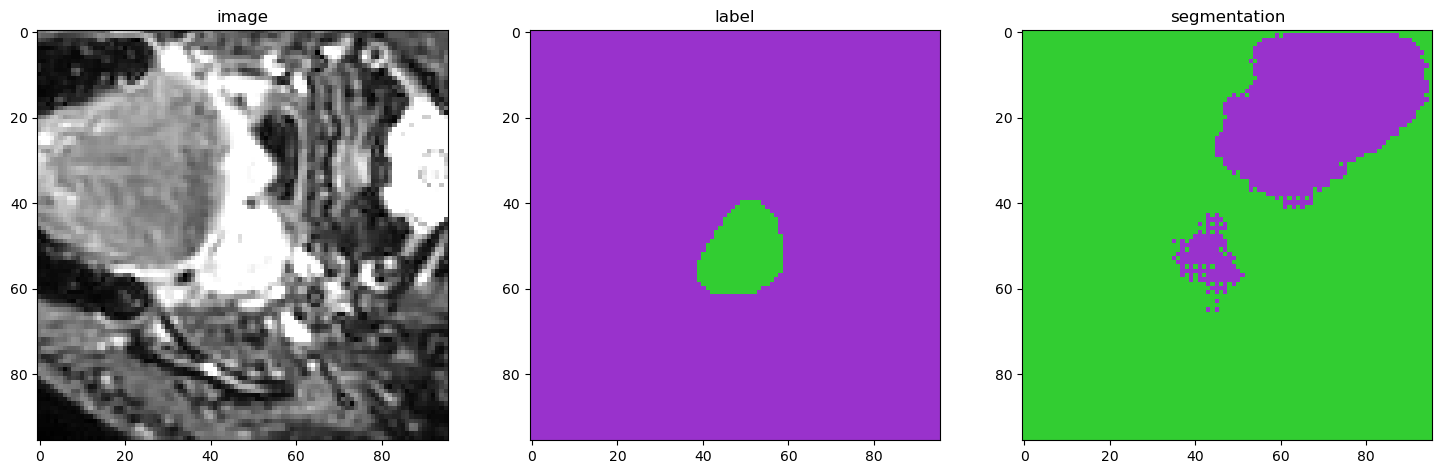

torch.Size([8, 1, 96, 96, 96])


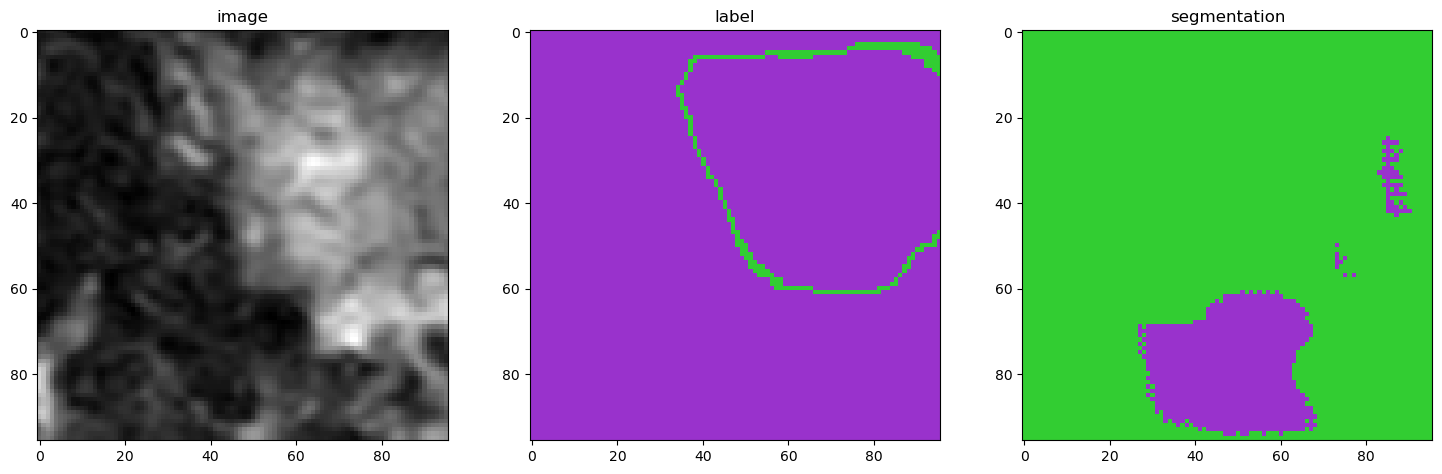

torch.Size([8, 1, 96, 96, 96])


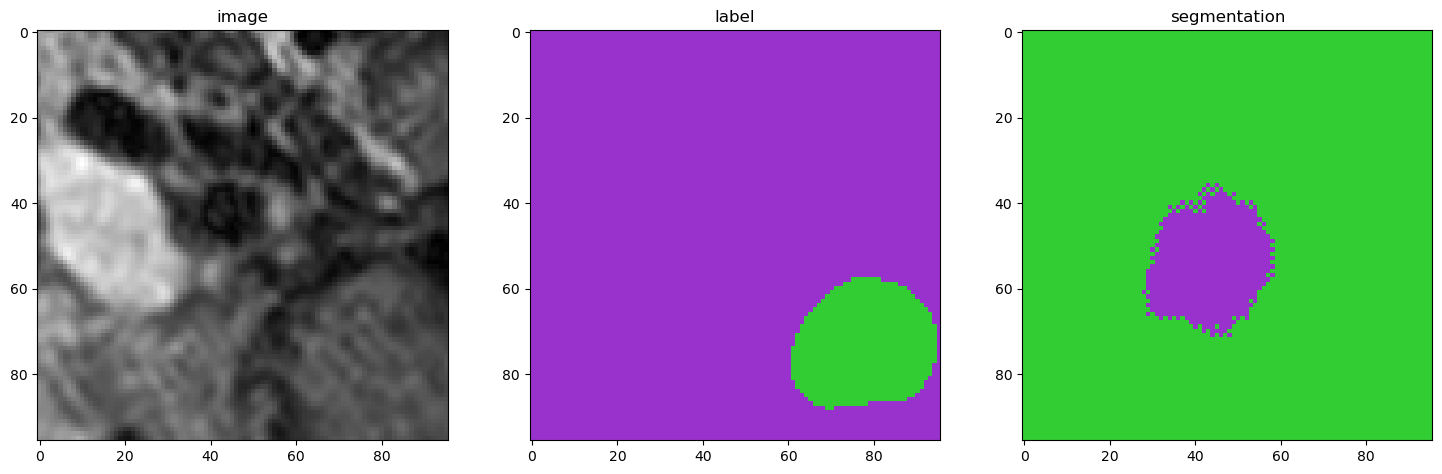

In [27]:
import matplotlib.colors
colors = ["darkorchid", "crimson", "limegreen"]
cmap = matplotlib.colors.ListedColormap(colors)

test_loader = get_test_loader(batch_size, data_dir, fold, roi)

# model.load_state_dict(torch.load("./models/best_model_fold5.pth", weights_only=True))

model.eval()

from monai.inferers import SlidingWindowInferer

model_inferer_test = SlidingWindowInferer(roi_size=[128, 128, 128], sw_batch_size=4, overlap=0.6)

"""    
partial(
    sliding_window_inference,
    roi_size= [128,128,128], # [roi[0], roi[1], roi[2]],
    sw_batch_size=4, # 1
    predictor=model,
    overlap=0.6, # 0.6
))
"""

all_seg_out = dict()

slice_num = 35

with torch.no_grad():
    for batch_data in train_loader:
        image = batch_data["image"].cuda()
        
        logits = model_inferer_test(image, network=model)  # shape: [B, C, D, H, W]
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()

        for b in range(preds.shape[0]):
            pred = preds[b].cpu().numpy()  # shape: [C, D, H, W]

            # Convert to single-channel mask
            seg_out = np.zeros(pred.shape[1:], dtype=np.uint8)
            if pred.shape[0] >= 1:
                seg_out[pred[0] == 1] = 1
            if pred.shape[0] >= 2:
                seg_out[pred[1] == 1] = 2
                
        print(batch_data["image"].shape)
        
        # Find a slice where we can see tumors
        slice_num = 65
        for i in range(10,90):
            if len(np.unique(batch_data["mask"][0,0,:,:,i])) > 1:
                slice_num = i + 10
                break
                
        img = batch_data["image"].cpu().numpy()[0,0,:, :, slice_num]
        label = batch_data["mask"].cpu().numpy()[0,0,:, :, slice_num]
        plt.figure("image", (18, 6))
        plt.subplot(1, 3, 1)
        plt.title("image")
        plt.imshow(img, cmap="gray")
        plt.subplot(1, 3, 2)
        plt.title("label")
        plt.imshow(label, cmap=cmap)
        plt.subplot(1, 3, 3)
        plt.title("segmentation")
        plt.imshow(seg_out[:, :, slice_num], cmap=cmap)
        plt.show()
        
        """
        prob = torch.sigmoid(model_inferer_test(image))
        print(prob.shape)
        seg = prob[0].detach().cpu().numpy()
        seg = (seg > 0.5).astype(np.int8)
        seg_out = np.zeros((seg.shape[1], seg.shape[2], seg.shape[3]))
        seg_out[seg[0] == 1] = 1
        seg_out[seg[1] == 1] = 2
        """

Visualize output and compare with label

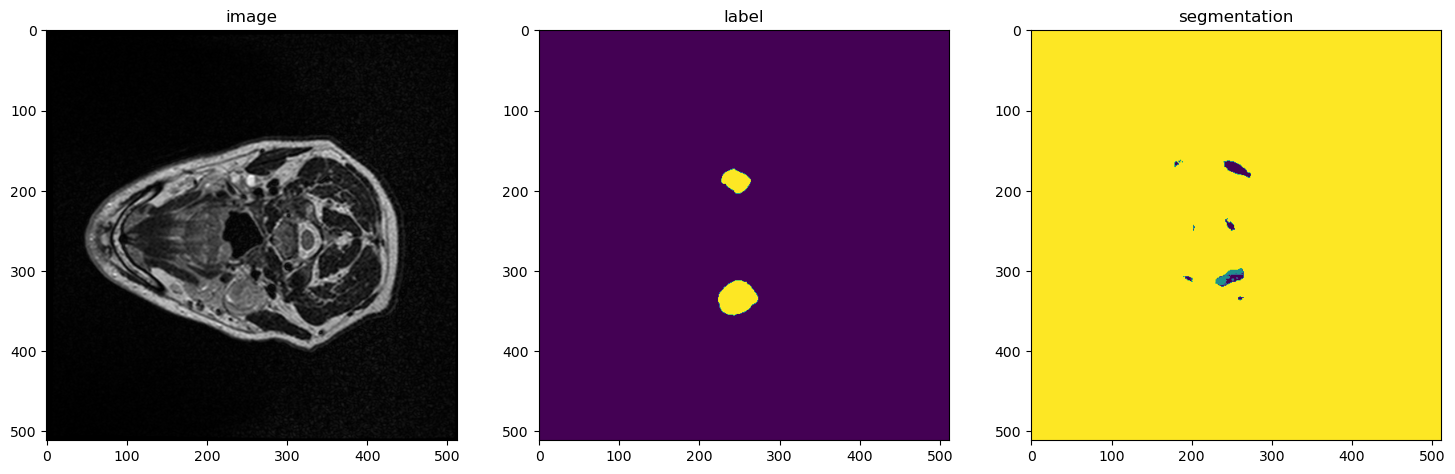

In [18]:
slice_num = 35
case_num = 8

img_add = data_dir + "/test/" + str(case_num) + "/preRT/" + str(case_num) + "_preRT_T2.nii.gz"
label_add = data_dir + "/test/" + str(case_num) + "/preRT/" + str(case_num) + "_preRT_mask.nii.gz"

img = nib.load(img_add).get_fdata()
label = nib.load(label_add).get_fdata()
plt.figure("image", (18, 6))
plt.subplot(1, 3, 1)
plt.title("image")
plt.imshow(img[:, :, slice_num], cmap="gray")
plt.subplot(1, 3, 2)
plt.title("label")
plt.imshow(label[:, :, slice_num])
plt.subplot(1, 3, 3)
plt.title("segmentation")
plt.imshow(seg_out[:, :, slice_num])
plt.show()

Export .nii.gz file for visualization

In [ ]:
# Load the original image (to get affine and header)
img_nib = nib.load(data_dir + "/test/" + str(case_num) + "/preRT/" + str(case_num) + "_preRT_T2.nii.gz")

# Create new NIfTI image
seg_nib = nib.Nifti1Image(seg_out.astype(np.uint8), affine=img_nib.affine, header=img_nib.header)

# Save
nib.save(seg_nib, "~/medsegout/segmentation_output.nii.gz")